In [ ]:
# Loading Dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Databases Procesados
import zipfile
import os

# Define the zip file path
zip_path = "/content/drive/MyDrive/Mis ML Modelos/Modelos_Semanticos/Semantic_Analysis_DynaSent/balanced_datasets.zip"

# Unzip into /content/
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/")

print("✅ Unzipped balanced_datasets.zip into /content/")

import pandas as pd

# Dynasent - Lemma
balanced_train_Dynasent_lemma = pd.read_csv("/content/balanced_train_Dynasent_lemma.csv")
balanced_test_Dynasent_lemma = pd.read_csv("/content/balanced_test_Dynasent_lemma.csv")
balanced_val_Dynasent_lemma = pd.read_csv("/content/balanced_val_Dynasent_lemma.csv")

# Dynasent - Clean
balanced_train_Dynasent_clean = pd.read_csv("/content/balanced_train_Dynasent_clean.csv")
balanced_test_Dynasent_clean = pd.read_csv("/content/balanced_test_Dynasent_clean.csv")
balanced_val_Dynasent_clean = pd.read_csv("/content/balanced_val_Dynasent_clean.csv")

# Dynasent - Original
balanced_train_Dynasent_original = pd.read_csv("/content/balanced_train_Dynasent_original.csv")
balanced_test_Dynasent_original = pd.read_csv("/content/balanced_test_Dynasent_original.csv")
balanced_val_Dynasent_original = pd.read_csv("/content/balanced_val_Dynasent_original.csv")



print("✅ All CSVs loaded into pandas DataFrames.")




✅ Unzipped balanced_datasets.zip into /content/
✅ All CSVs loaded into pandas DataFrames.


# Data Exploration

In [ ]:

!unzip '/content/drive/MyDrive/SERDATABASES/dynasent-v1.1.zip'

#!unzip dynasent-v1.1.zip -d dynasent-v1.1

Archive:  /content/drive/MyDrive/SERDATABASES/IMBD.zip
  inflating: IMDB Dataset.csv        
Archive:  /content/drive/MyDrive/SERDATABASES/dynasent-v1.1.zip
   creating: dynasent-v1.1/
  inflating: dynasent-v1.1/dynasent-v1.1-round01-yelp-train.jsonl  
   creating: __MACOSX/
   creating: __MACOSX/dynasent-v1.1/
  inflating: __MACOSX/dynasent-v1.1/._dynasent-v1.1-round01-yelp-train.jsonl  
  inflating: dynasent-v1.1/dynasent-v1.1-round01-yelp-dev.jsonl  
  inflating: dynasent-v1.1/dynasent-v1.1-round02-dynabench-test.jsonl  
  inflating: __MACOSX/dynasent-v1.1/._dynasent-v1.1-round02-dynabench-test.jsonl  
  inflating: dynasent-v1.1/dynasent-v1.1-round02-dynabench-dev.jsonl  
  inflating: __MACOSX/dynasent-v1.1/._dynasent-v1.1-round02-dynabench-dev.jsonl  
  inflating: dynasent-v1.1/dynasent-v1.1-round02-dynabench-train.jsonl  
  inflating: __MACOSX/dynasent-v1.1/._dynasent-v1.1-round02-dynabench-train.jsonl  
  inflating: dynasent-v1.1/sst-dev-validated.jsonl  
  inflating: __MACOSX/dy

In [ ]:
# Import necessary libraries
import zipfile
import os
import json
import random
from collections import Counter
import pandas as pd
import tensorflow as tf
from transformers import TFBertForSequenceClassification, BertTokenizer

train_filename = '/content/dynasent-v1.1/dynasent-v1.1-round01-yelp-train.jsonl'
val_filename = '/content/dynasent-v1.1/dynasent-v1.1-round01-yelp-dev.jsonl'
test_filename = '/content/dynasent-v1.1/dynasent-v1.1-round01-yelp-test.jsonl'

# Load and filter the dataset for ternary labels
def load_dataset(filename, labels=None):
    data = []
    with open(filename) as f:
        for line in f:
            d = json.loads(line)
            if labels is None or d['gold_label'] in labels:
                data.append(d)
    return data

# Convert the loaded data into a DataFrame format with numeric labels and descriptions
def convert_to_dataframe(dataset):
    # Mapping for labels
    label_mapping = {'negative': 0, 'neutral': 1, 'positive': 2}
    # Extract relevant fields and add both numeric labels and descriptions
    df = pd.DataFrame([
        {
            'Text': d['sentence'],
            'Label': label_mapping[d['gold_label']],  # Numeric label
            'Description': d['gold_label']      # Description label
        }
        for d in dataset
    ])
    return df

# Load datasets with ternary labels
labels = ['positive', 'neutral', 'negative']
train_data = load_dataset(train_filename, labels)
val_data = load_dataset(val_filename, labels)
test_data = load_dataset(test_filename, labels)

# Convert datasets to DataFrames with numeric labels and descriptions
train_Dynasent = convert_to_dataframe(train_data)
val_Dynasent = convert_to_dataframe(val_data)
test_Dynasent = convert_to_dataframe(test_data)

# Display the first few rows to verify
print("Train Data:")
print(train_Dynasent.head())
print("\nValidation Data:")
print(val_Dynasent.head())
print("\nTest Data:")
print(test_Dynasent.head())




Train Data:
                                                Text  Label Description
0  Roto-Rooter is always good when you need someo...      2    positive
1  It's so worth the price of cox service over he...      2    positive
2  I placed my order of "sticky ribs" as an appet...      1     neutral
3  There is mandatory valet parking, so make sure...      1     neutral
4                  My wife and I couldn't finish it.      1     neutral

Validation Data:
                                                Text  Label Description
0  He didn't just try to shove medication down he...      2    positive
1  When we saw that it became a Vietnamese place ...      1     neutral
2                          Brewery nachos were good.      2    positive
3  I really loved Alma, which was here before, an...      2    positive
4  I'm withholding one star because there's too m...      0    negative

Test Data:
                                                Text  Label Description
0           Had to rem

In [ ]:
# Function to count the number of 'joy' and 'sadness' texts
def count_emotions(dataset):
    counts = dataset['Description'].value_counts()
    return counts[['positive', 'neutral', 'negative']]

# Counting for train set
train_counts = count_emotions(train_Dynasent)

# Counting for validation set
val_counts = count_emotions(val_Dynasent)

# Counting for test set
test_counts = count_emotions(test_Dynasent)

# Displaying the counts
print("Train Set:")
print(train_counts)
print(train_Dynasent.shape)

print("\nValidation Set:")
print(val_counts)
print(val_Dynasent.shape)

print("\nTest Set:")
print(test_counts)
print(test_Dynasent.shape)

Train Set:
Description
positive    21391
neutral     45076
negative    14021
Name: count, dtype: int64
(80488, 3)

Validation Set:
Description
positive    1200
neutral     1200
negative    1200
Name: count, dtype: int64
(3600, 3)

Test Set:
Description
positive    1200
neutral     1200
negative    1200
Name: count, dtype: int64
(3600, 3)


In [ ]:
# Set the target number of samples for each emotion in each set
target_samples_train_Dynasent = {'positive': 14021, 'neutral': 14021, 'negative': 14021}
target_samples_val_Dynasent = {'positive': 1200, 'neutral': 1200, 'negative': 1200}
target_samples_test_Dynasent = {'positive': 1200, 'neutral': 1200, 'negative': 1200}

# Function to balance the dataset for joy and sadness
def balance_dataset(dataset, target_samples):
    balanced_data = pd.DataFrame()

    for emotion, target_count in target_samples.items():
        subset = dataset[dataset['Description'] == emotion].sample(n=target_count, random_state=42)
        balanced_data = pd.concat([balanced_data, subset])

    return balanced_data

# Create new balanced datasets for each set
balanced_train_Dynasent = balance_dataset(train_Dynasent, target_samples_train_Dynasent)
balanced_val_Dynasent = balance_dataset(val_Dynasent, target_samples_val_Dynasent)
balanced_test_Dynasent = balance_dataset(test_Dynasent, target_samples_test_Dynasent)

# Displaying the shape of the new balanced datasets
print("Shape of Balanced Train Set:", balanced_train_Dynasent.shape)
print("Shape of Balanced Validation Set:", balanced_val_Dynasent.shape)
print("Shape of Balanced Test Set:", balanced_test_Dynasent.shape)

Shape of Balanced Train Set: (42063, 3)
Shape of Balanced Validation Set: (3600, 3)
Shape of Balanced Test Set: (3600, 3)


In [ ]:
# Copia Originales
balanced_train_Dynasent_original = balanced_train_Dynasent.copy()
balanced_val_Dynasent_original= balanced_val_Dynasent.copy()
balanced_test_Dynasent_original= balanced_test_Dynasent.copy()


## Preprocesamiento

In [ ]:
import re
# Optimized preprocessing function
def preprocess(df, text_column='Text'):
    df = df.copy()  # Ensure we're working on a copy
    df[text_column] = df[text_column].replace(regex=['<br />', '\n'], value=' ')

    def clean_text(text):
        if not isinstance(text, str):
            return ''
        text = text.lower()
        text = re.sub(r'[^\w\s]', '', text)  # Remove punctuation/special characters
        text = re.sub(r'\s+', ' ', text).strip()  # Normalize whitespace
        return text

    df[text_column] = df[text_column].apply(clean_text)
    return df

In [ ]:
# CLEAN
balanced_train_Dynasent = preprocess(balanced_train_Dynasent)
balanced_val_Dynasent= preprocess(balanced_val_Dynasent)
balanced_test_Dynasent= preprocess(balanced_test_Dynasent)


In [ ]:
import nltk
from nltk.corpus import stopwords

# Download stopwords if not already downloaded
nltk.download('stopwords')

# Load default English stopwords
stop_words = set(stopwords.words('english'))

# Define words to retain (do NOT remove these)
retain_words = {
    'no', 'nor', 'not', 'none', 'nobody', 'nothing', 'nowhere', 'never', 'neither',
    'but', 'however', 'although', 'though', 'even', 'yet', 'still', 'except', 'rather', 'despite'
}

# Remove retained words from the stopword list
custom_stopwords = stop_words - retain_words

# Function to remove stopwords (except retained ones)
def remove_stopwords(text):
    return ' '.join([word for word in text.split() if word.lower() not in custom_stopwords])



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
# Apply to your dataset

balanced_train_Dynasent['Text'] = balanced_train_Dynasent['Text'].apply(remove_stopwords)
balanced_val_Dynasent['Text'] = balanced_val_Dynasent['Text'].apply(remove_stopwords)
balanced_test_Dynasent['Text'] = balanced_test_Dynasent['Text'].apply(remove_stopwords)


In [ ]:
# 1) Print the shape of each original DataFrame
print("Train shape:", balanced_train_Dynasent.shape)
print("Val shape:", balanced_val_Dynasent.shape)
print("Test shape:", balanced_test_Dynasent.shape)

# 2) Identify rows where Text is missing in each DataFrame
missing_train = balanced_train_Dynasent[balanced_train_Dynasent["Text"].isna()]
missing_val = balanced_val_Dynasent[balanced_val_Dynasent["Text"].isna()]
missing_test = balanced_test_Dynasent[balanced_test_Dynasent["Text"].isna()]

# 3) Print the shape of missing rows (if any)
print("\nTrain missing shape:", missing_train.shape)
print(missing_train)

print("\nVal missing shape:", missing_val.shape)
print(missing_val)

print("\nTest missing shape:", missing_test.shape)
print(missing_test)

Train shape: (42001, 3)
Val shape: (3594, 3)
Test shape: (3592, 3)

Train missing shape: (0, 3)
Empty DataFrame
Columns: [Text, Label, Description]
Index: []

Val missing shape: (0, 3)
Empty DataFrame
Columns: [Text, Label, Description]
Index: []

Test missing shape: (0, 3)
Empty DataFrame
Columns: [Text, Label, Description]
Index: []


In [ ]:
balanced_train_Dynasent = balanced_train_Dynasent.dropna(subset=['Text'])
balanced_train_Dynasent = balanced_train_Dynasent[balanced_train_Dynasent['Text'].str.strip() != '']

balanced_val_Dynasent = balanced_val_Dynasent.dropna(subset=['Text'])
balanced_val_Dynasent = balanced_val_Dynasent[balanced_val_Dynasent['Text'].str.strip() != '']

balanced_test_Dynasent = balanced_test_Dynasent.dropna(subset=['Text'])
balanced_test_Dynasent = balanced_test_Dynasent[balanced_test_Dynasent['Text'].str.strip() != '']

# 1) Print the shape of each original DataFrame
print("Train shape:", balanced_train_Dynasent.shape)
print("Val shape:", balanced_val_Dynasent.shape)
print("Test shape:", balanced_test_Dynasent.shape)

Train shape: (42001, 3)
Val shape: (3594, 3)
Test shape: (3592, 3)


In [ ]:
# Copia clean
balanced_train_Dynasent_clean = balanced_train_Dynasent.copy()
balanced_val_Dynasent_clean= balanced_val_Dynasent.copy()
balanced_test_Dynasent_clean= balanced_test_Dynasent.copy()


In [ ]:
import spacy
from collections import Counter

# Load spaCy English model (disable NER and parser for speed)
nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])

def Lemmatizer(df, text_column='Text'):

    # Ensure text is string and not null
    df[text_column] = df[text_column].astype(str).fillna('')

    # Process texts with spaCy
    docs = list(nlp.pipe(df[text_column].tolist(), batch_size=32))

    # Lemmatize and clean
    cleaned_texts = []
    for doc in docs:
        tokens = [
            token.lemma_.lower()
            for token in doc
        ]
        cleaned_texts.append(" ".join(tokens))

    # Add cleaned column temporarily
    df['Text'] = cleaned_texts



    # Return only cleaned text and label
    return df[['Text', 'Label', 'Description']]


In [ ]:
# LEMMA
balanced_train_Dynasent = Lemmatizer(balanced_train_Dynasent)
balanced_val_Dynasent= Lemmatizer(balanced_val_Dynasent)
balanced_test_Dynasent= Lemmatizer(balanced_test_Dynasent)

In [ ]:
# Copia Lemma
balanced_train_Dynasent_lemma = balanced_train_Dynasent.copy()
balanced_val_Dynasent_lemma= balanced_val_Dynasent.copy()
balanced_test_Dynasent_lemma= balanced_test_Dynasent.copy()

In [ ]:
# Combine the two datasets side-by-side
Compare_Dynasent = pd.DataFrame({
    'Original_Text': balanced_train_Dynasent_original['Text'],
    'Clean_Text': balanced_train_Dynasent_clean['Text'],
    'Lemma_Text': balanced_train_Dynasent_lemma['Text'],
    'Label': balanced_train_Dynasent['Label'],
    'Description': balanced_train_Dynasent['Description']
})

# Display the combined table
Compare_Dynasent

,Original_Text,Clean_Text,Lemma_Text,Label,Description
0,Roto-Rooter is always good when you need someo...,rotorooter always good need someone right away,rotorooter always good need someone right away,2.0,positive
2,"I placed my order of ""sticky ribs"" as an appet...",placed order sticky ribs appetizer angry chick...,place order sticky rib appetizer angry chicken...,1.0,neutral
3,"There is mandatory valet parking, so make sure...",mandatory valet parking make sure get everythi...,mandatory valet parking make sure get everythi...,1.0,neutral
6,I found out that the restaurant has only been ...,found restaurant open week,find restaurant open week,1.0,neutral
7,"I suffer with high blood pressure, headaches, ...",suffer high blood pressure headaches type 2 di...,suffer high blood pressure headache type 2 dia...,0.0,negative
...,...,...,...,...,...
80476,They offered a coupon for free breadsticks if ...,offered coupon free breadsticks spend 20 aweso...,offer coupon free breadstick spend 20 awesome ...,2.0,positive
80478,This is pricey.,pricey,pricey,0.0,negative
80479,He made additional adjustments to correct.,made additional adjustments correct,make additional adjustment correct,2.0,positive
80484,I have never been cussed out and told someone ...,never cussed told someone didnt want business ...,never cuss tell someone do not want business e...,0.0,negative


In [ ]:
import pandas as pd
import zipfile
import os

# Save all dataframes with distinct names
balanced_train_Dynasent_lemma.to_csv("balanced_train_Dynasent_lemma.csv", index=False)
balanced_test_Dynasent_lemma.to_csv("balanced_test_Dynasent_lemma.csv", index=False)
balanced_val_Dynasent_lemma.to_csv("balanced_val_Dynasent_lemma.csv", index=False)

balanced_train_Dynasent_clean.to_csv("balanced_train_Dynasent_clean.csv", index=False)
balanced_test_Dynasent_clean.to_csv("balanced_test_Dynasent_clean.csv", index=False)
balanced_val_Dynasent_clean.to_csv("balanced_val_Dynasent_clean.csv", index=False)

balanced_train_Dynasent_original.to_csv("balanced_train_Dynasent_original.csv", index=False)
balanced_test_Dynasent_original.to_csv("balanced_test_Dynasent_original.csv", index=False)
balanced_val_Dynasent_original.to_csv("balanced_val_Dynasent_original.csv", index=False)


# Zip all CSVs
csv_files = [f for f in os.listdir() if f.startswith("balanced_") and f.endswith(".csv")]
with zipfile.ZipFile("balanced_datasets.zip", "w") as zipf:
    for file in csv_files:
        zipf.write(file)

print("Zipped all datasets into balanced_datasets.zip")



Zipped all datasets into balanced_datasets.zip


In [ ]:
import shutil

src_path = "/content/balanced_datasets.zip"
dst_path = "/content/drive/MyDrive/Mis ML Modelos/Modelos_Semanticos/DynaSent_Thesis/balanced_datasets.zip"

shutil.copy(src_path, dst_path)
print(" Copied successfully.")

 Copied successfully.


In [ ]:
# Stad on Train

import numpy as np
import pandas as pd
import string

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# Style setup
sns.set(style='whitegrid', palette='muted', font_scale=1.2)
colors = ["#01BEFE", "#FFDD00", "#FF7D00", "#FF006D", "#ADFF02", "#8F00FF"]
sns.set_palette(sns.color_palette(colors))
matplotlib.rcParams['figure.figsize'] = 12, 6


balanced_train_Dynasent_original['text_length'] = balanced_train_Dynasent_original['Text'].astype(str).apply(len)
balanced_train_Dynasent_original['text_word_count'] = balanced_train_Dynasent_original['Text'].apply(lambda x: len(str(x).split()))

balanced_train_Dynasent_clean['text_length'] = balanced_train_Dynasent_clean['Text'].astype(str).apply(len)
balanced_train_Dynasent_clean['text_word_count'] = balanced_train_Dynasent_clean['Text'].apply(lambda x: len(str(x).split()))

balanced_train_Dynasent_lemma['text_length'] = balanced_train_Dynasent_lemma['Text'].astype(str).apply(len)
balanced_train_Dynasent_lemma['text_word_count'] = balanced_train_Dynasent_lemma['Text'].apply(lambda x: len(str(x).split()))


mean_original = balanced_train_Dynasent_original['text_word_count'].mean()
mean_clean = balanced_train_Dynasent_clean['text_word_count'].mean()
mean_lemma = balanced_train_Dynasent_lemma['text_word_count'].mean()

mean_original, mean_clean, mean_lemma




(np.float64(13.99172669567078),
 np.float64(7.288826456512941),
 np.float64(7.5009880717125785))

In [ ]:
max_original = balanced_train_Dynasent_original['text_word_count'].max()
max_clean = balanced_train_Dynasent_clean['text_word_count'].max()
max_lemma = balanced_train_Dynasent_lemma['text_word_count'].max()

max_original, max_clean, max_lemma

(258, 130, 131)

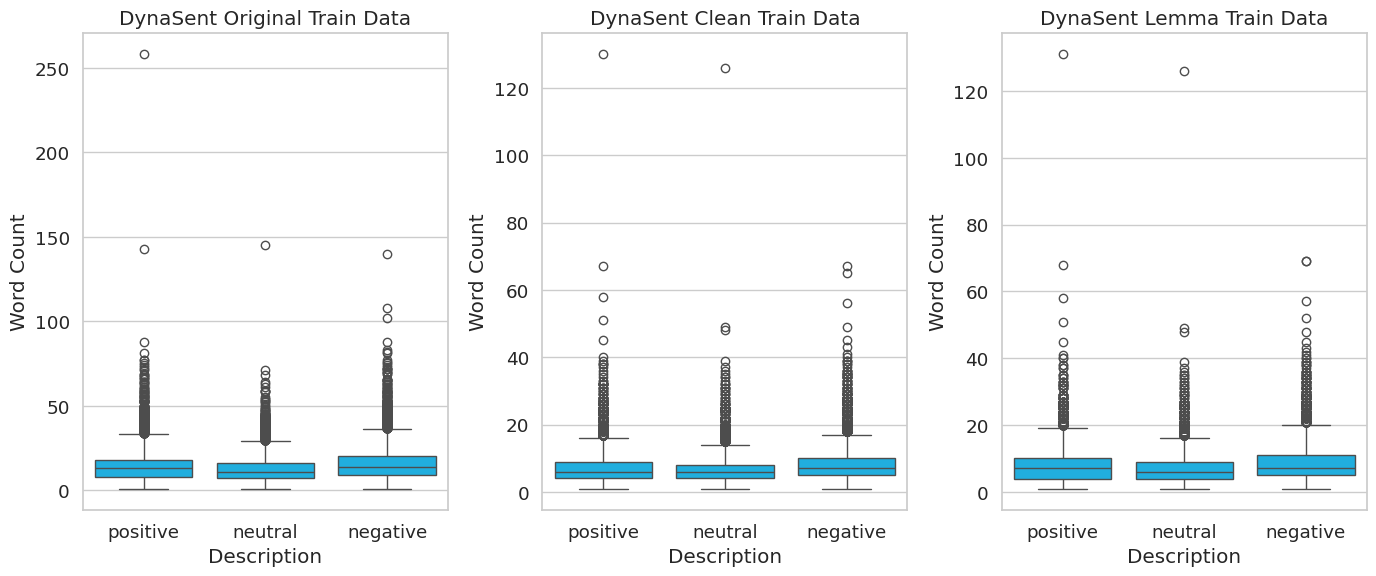

In [ ]:
# Boxplot comparison of word count by emotion
fig, axes = plt.subplots(ncols=3, figsize=(14, 6))

# MyDynaSent boxplot
sns.boxplot(x="Description", y="text_word_count", data=balanced_train_Dynasent_original, ax=axes[0])
axes[0].set_title("DynaSent Original Train Data")
axes[0].set_xlabel("Description")
axes[0].set_ylabel("Word Count")

# MyDynaSent boxplot
sns.boxplot(x="Description", y="text_word_count", data=balanced_train_Dynasent_clean, ax=axes[1])
axes[1].set_title("DynaSent Clean Train Data")
axes[1].set_xlabel("Description")
axes[1].set_ylabel("Word Count")

# MyDynaSent boxplot
sns.boxplot(x="Description", y="text_word_count", data=balanced_train_Dynasent_lemma, ax=axes[2])
axes[2].set_title("DynaSent Lemma Train Data")
axes[2].set_xlabel("Description")
axes[2].set_ylabel("Word Count")

plt.tight_layout()
plt.show()

Total tokens: 315049


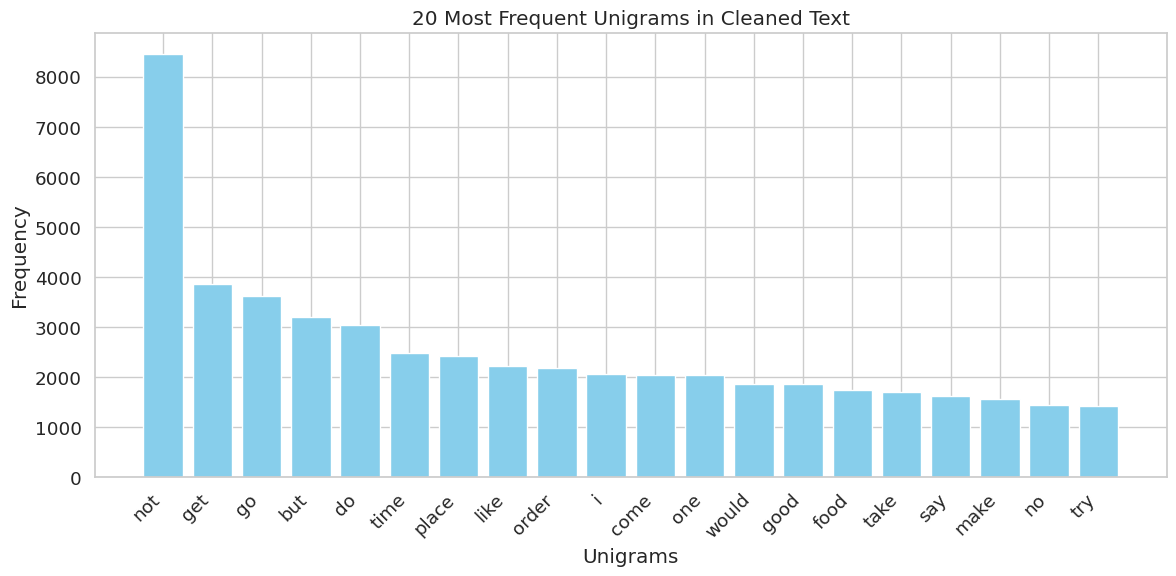

Number of unique words in original text: 48712
Number of unique words in cleaned text: 24093
Number of unique words in lemma text: 20049


In [ ]:
from collections import Counter
import matplotlib.pyplot as plt

# Calculate the unique words in the original 'Text' column
all_original_words = " ".join(balanced_train_Dynasent_original['Text'].astype(str)).split()
unique_original_words = set(all_original_words)

# Calculate the unique words in the clean 'Text' column
all_clean_words = " ".join(balanced_train_Dynasent_clean['Text'].astype(str)).split()
unique_clean_words = set(all_clean_words)

# Calculate the unique words in the lemma 'Text' column
all_lemma_words = " ".join(balanced_train_Dynasent_lemma['Text'].astype(str)).split()
unique_lemma_words = set(all_lemma_words)

# Choose which version of text to analyze for frequent tokens (e.g., clean)
text_to_analyze = " ".join(balanced_train_Dynasent_lemma['Text'].astype(str))
tokens = text_to_analyze.split()

# Total number of tokens
total_tokens = len(tokens)
print(f"Total tokens: {total_tokens}")

# Count frequency of each unigram
unigram_counts = Counter(tokens)

# Get the 20 most common unigrams
most_common_unigrams = unigram_counts.most_common(20)

# Separate unigrams and their frequencies for plotting
unigrams, counts = zip(*most_common_unigrams)

# Plot the 20 most common unigrams
plt.figure(figsize=(12, 6))
plt.bar(unigrams, counts, color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.title('20 Most Frequent Unigrams in Cleaned Text')
plt.xlabel('Unigrams')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# Display the number of unique words
print(f"Number of unique words in original text: {len(unique_original_words)}")
print(f"Number of unique words in cleaned text: {len(unique_clean_words)}")
print(f"Number of unique words in lemma text: {len(unique_lemma_words)}")

# The Rocchio Model

## DynaSent

### Train

,Dataset,Accuracy,Precision (0),Recall (0),F1-Score (0),Precision (1),Recall (1),F1-Score (1),Precision (2),Recall (2),F1-Score (2)
0,DynaSent_clean,0.595437,0.582465,0.559633,0.570821,0.552751,0.714047,0.623130,0.685619,0.512927,0.586832
1,DynaSent_lemma,0.571786,0.585938,0.437865,0.501193,0.521943,0.745819,0.614114,0.645096,0.532110,0.583181
2,DynaSent_original,0.575278,0.533011,0.551667,0.542179,0.578868,0.639167,0.607525,0.621491,0.535000,0.575011


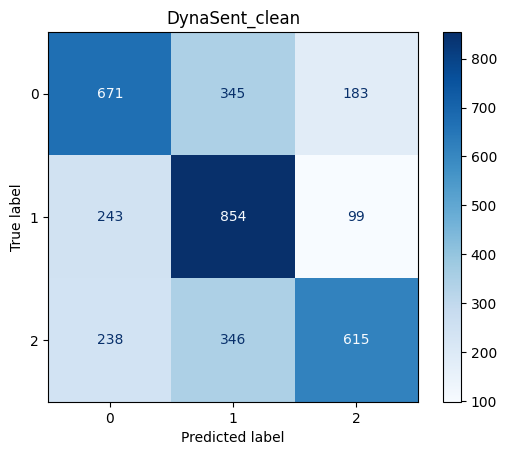

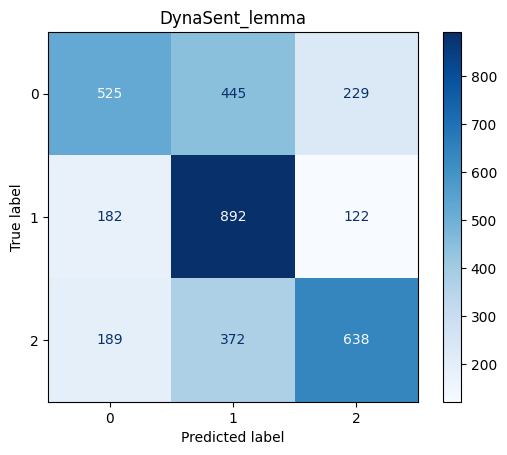

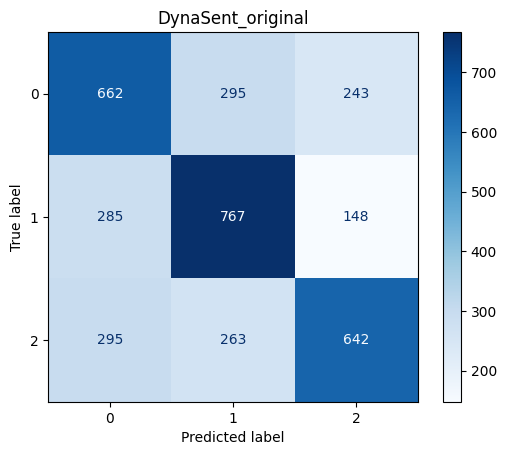

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib  # for saving/loading models
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# List of dataset tuples (define or load beforehand)
datasets = [
    (balanced_train_Dynasent_clean, balanced_val_Dynasent_clean, "DynaSent_clean"),
    (balanced_train_Dynasent_lemma, balanced_val_Dynasent_lemma, "DynaSent_lemma"),
    (balanced_train_Dynasent_original, balanced_val_Dynasent_original, "DynaSent_original")
]

# Evaluation + Save Function
def evaluate_and_save_model(X_train, y_train, X_test, y_test, class_labels, dataset_name):
    vectorizer = TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=1,
        max_df=0.8,
        sublinear_tf=True
    )
    X_train_tfidf = vectorizer.fit_transform(X_train)
    X_test_tfidf = vectorizer.transform(X_test)

    class_centroids = np.array([
        X_train_tfidf[y_train == label].mean(axis=0).A1
        for label in np.unique(y_train)
    ])

    def predict(X_tfidf):
        distances = euclidean_distances(X_tfidf, class_centroids)
        return np.argmin(distances, axis=1)

    y_pred = predict(X_test_tfidf)
    report = classification_report(y_test, y_pred, output_dict=True)
    accuracy = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    # Save the model
    joblib.dump({
        'vectorizer': vectorizer,
        'centroids': class_centroids,
        'label_encoder': class_labels
    }, f'{dataset_name}_centroid_model.pkl')

    metrics = {
        "Dataset": dataset_name,
        "Accuracy": accuracy,
        "confusion_matrix": cm,
    }

    for idx, class_label in enumerate(class_labels):
        metrics.update({
            f"Precision ({class_label})": report[str(idx)]["precision"],
            f"Recall ({class_label})": report[str(idx)]["recall"],
            f"F1-Score ({class_label})": report[str(idx)]["f1-score"]
        })

    return metrics

# Loop through datasets
all_results = []
for train_df, test_df, name in datasets:
    X_train = train_df["Text"]
    y_train_raw = train_df["Label"]
    X_test = test_df["Text"]
    y_test_raw = test_df["Label"]

    label_encoder = LabelEncoder()
    y_train = label_encoder.fit_transform(y_train_raw)
    y_test = label_encoder.transform(y_test_raw)
    class_labels = label_encoder.classes_

    results = evaluate_and_save_model(X_train, y_train, X_test, y_test, class_labels, name)
    all_results.append(results)

# Save summary
summary_df = pd.DataFrame([{k: v for k, v in r.items() if k != "confusion_matrix"} for r in all_results])
#summary_df.to_csv("evaluation_summary.csv", index=False)
display(summary_df)

# Confusion matrix plots
for res in all_results:
    cm = res["confusion_matrix"]
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.title(res["Dataset"])
    plt.show()


In [ ]:
import shutil

src_path = "/content/DynaSent_lemma_centroid_model.pkl"
dst_path = "/content/drive/MyDrive/Mis ML Modelos/Modelos_Semanticos/Semantic_Analysis_DynaSent/DynaSent_lemma_centroid_model.pkl"

shutil.copy(src_path, dst_path)
print("Model copied successfully.")

Model copied successfully.


### Eval

In [ ]:
# MyValidationDataset
import numpy as np
import joblib  # for saving/loading models
from sklearn.metrics.pairwise import euclidean_distances
# Load the saved model
model = joblib.load("/content/drive/MyDrive/Mis ML Modelos/Modelos_Semanticos/Semantic_Analysis_DynaSent/DynaSent_clean_centroid_model.pkl")
vectorizer = model["vectorizer"]
centroids = model["centroids"]
class_labels = model["label_encoder"]  # This is already in class order (e.g., ['negative', 'neutral', 'positive'])

# Define new texts
new_texts = [
    "Great", "Amazing", "Well done", "Terrible", "Pathetic", "Poorly done",
    "Oooh, wow!", "That is terrific!", "That’s awesome!",
    "This is terrible!", "Absolutely awful!", "This is so disappointing!",
    "I wasn’t looking forward to it anyway", "Oh, this is just what I needed right now",
    "Really?", "Is that your best attempt?", "How could this possibly get any worse?",
    "How sweet the moonlight sleeps upon this bank!",
    "Blow, winds, and crack your cheeks! rage! blow! ",
    "Fair is foul, and foul is fair: Hover through the fog and filthy air."
]

# Vectorize and predict
new_tfidf = vectorizer.transform(new_texts)
distances = euclidean_distances(new_tfidf, centroids)
pred_indices = np.argmin(distances, axis=1)
pred_labels = [class_labels[i] for i in pred_indices]

# Show results
for text, label in zip(new_texts, pred_labels):
    print(f"Text: {text}\n → Predicted Sentiment: {label}\n")

Text: Great
 → Predicted Sentiment: 2

Text: Amazing
 → Predicted Sentiment: 2

Text: Well done
 → Predicted Sentiment: 2

Text: Terrible
 → Predicted Sentiment: 0

Text: Pathetic
 → Predicted Sentiment: 1

Text: Poorly done
 → Predicted Sentiment: 1

Text: Oooh, wow!
 → Predicted Sentiment: 2

Text: That is terrific!
 → Predicted Sentiment: 1

Text: That’s awesome!
 → Predicted Sentiment: 2

Text: This is terrible!
 → Predicted Sentiment: 0

Text: Absolutely awful!
 → Predicted Sentiment: 0

Text: This is so disappointing!
 → Predicted Sentiment: 0

Text: I wasn’t looking forward to it anyway
 → Predicted Sentiment: 2

Text: Oh, this is just what I needed right now
 → Predicted Sentiment: 1

Text: Really?
 → Predicted Sentiment: 0

Text: Is that your best attempt?
 → Predicted Sentiment: 2

Text: How could this possibly get any worse?
 → Predicted Sentiment: 0

Text: How sweet the moonlight sleeps upon this bank!
 → Predicted Sentiment: 2

Text: Blow, winds, and crack your cheeks! rag


=== Sentiment Evaluation for DynaSent_clean ===
Accuracy: 0.5947
              precision    recall  f1-score   support

           0       0.57      0.54      0.56      1200
           1       0.56      0.72      0.63      1192
           2       0.68      0.52      0.59      1200

    accuracy                           0.59      3592
   macro avg       0.60      0.59      0.59      3592
weighted avg       0.60      0.59      0.59      3592



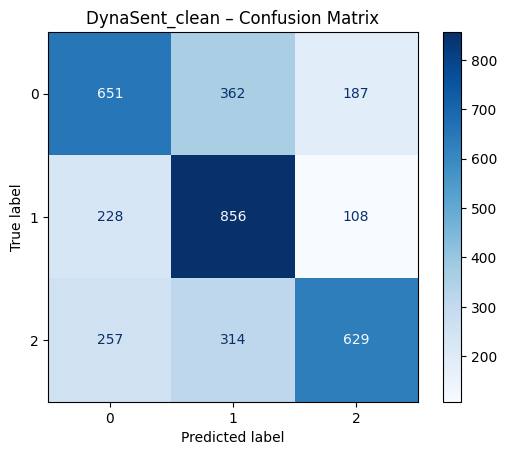


=== Sentiment Evaluation for DynaSent_original ===
Accuracy: 0.5850
              precision    recall  f1-score   support

           0       0.53      0.57      0.55      1200
           1       0.59      0.63      0.61      1200
           2       0.64      0.55      0.59      1200

    accuracy                           0.58      3600
   macro avg       0.59      0.58      0.59      3600
weighted avg       0.59      0.58      0.59      3600



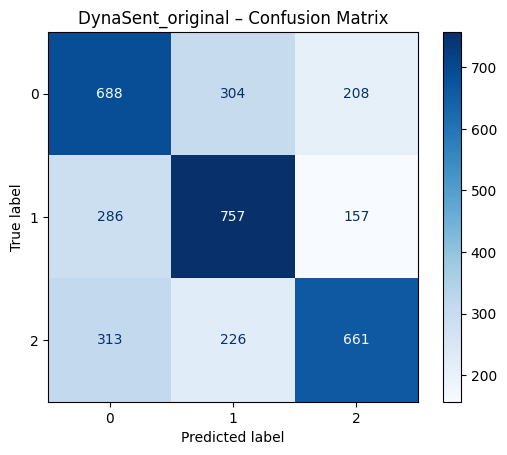


=== Sentiment Evaluation for DynaSent_lemma ===
Accuracy: 0.5877
              precision    recall  f1-score   support

           0       0.60      0.45      0.51      1200
           1       0.54      0.76      0.63      1192
           2       0.66      0.56      0.60      1200

    accuracy                           0.59      3592
   macro avg       0.60      0.59      0.58      3592
weighted avg       0.60      0.59      0.58      3592



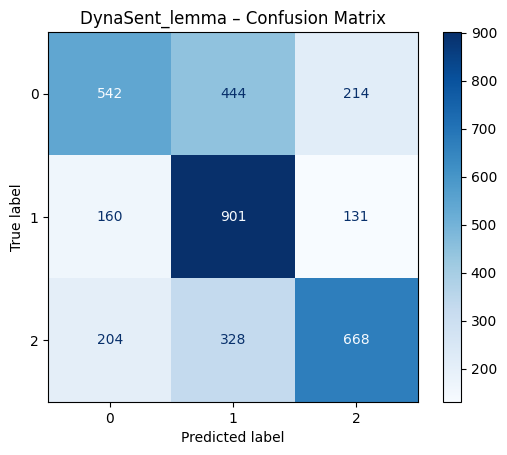

,Model,Accuracy,Precision (0),Recall (0),F1 (0),Precision (1),Recall (1),F1 (1),Precision (2),Recall (2),F1 (2),Macro F1,Weighted F1
0,DynaSent_clean,0.594655,0.573063,0.542500,0.557363,0.558747,0.718121,0.628488,0.680736,0.524167,0.592279,0.592710,0.592630
1,DynaSent_original,0.585000,0.534577,0.573333,0.553277,0.588190,0.630833,0.608766,0.644250,0.550833,0.593890,0.585311,0.585311
2,DynaSent_lemma,0.587695,0.598234,0.451667,0.514720,0.538553,0.755872,0.628970,0.659427,0.556667,0.603705,0.582465,0.582362


In [ ]:
import numpy as np
import pandas as pd
import joblib
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics.pairwise import euclidean_distances
import matplotlib.pyplot as plt

# Define your model paths
model_paths = {
    "DynaSent_clean": "/content/drive/MyDrive/Mis ML Modelos/Modelos_Semanticos/Semantic_Analysis_DynaSent/DynaSent_clean_centroid_model.pkl",
    "DynaSent_original": "/content/drive/MyDrive/Mis ML Modelos/Modelos_Semanticos/Semantic_Analysis_DynaSent/DynaSent_original_centroid_model.pkl",
    "DynaSent_lemma": "/content/drive/MyDrive/Mis ML Modelos/Modelos_Semanticos/Semantic_Analysis_DynaSent/DynaSent_lemma_centroid_model.pkl"
}

# Corresponding validation sets (ensure these DataFrames are loaded in your notebook)
test_sets = {
    "DynaSent_clean": balanced_test_Dynasent_clean,
    "DynaSent_original": balanced_test_Dynasent_original,
    "DynaSent_lemma": balanced_test_Dynasent_lemma
}

summary_data = []

# Loop through each model and validation set
for name in model_paths:
    print(f"\n=== Sentiment Evaluation for {name} ===")

    # Load model
    model = joblib.load(model_paths[name])
    vectorizer = model["vectorizer"]
    centroids = model["centroids"]
    class_labels = model["label_encoder"]
    class_names = [str(label) for label in class_labels]

    # Prepare label encoder
    label_encoder = LabelEncoder()
    label_encoder.classes_ = class_labels

    # Get validation DataFrame
    df = test_sets[name].dropna(subset=["Text", "Label"])

    # Prepare data
    X = df["Text"]
    y_true = label_encoder.transform(df["Label"])

    # Vectorize and predict
    X_tfidf = vectorizer.transform(X)
    distances = euclidean_distances(X_tfidf, centroids)
    y_pred = distances.argmin(axis=1)

    # Metrics
    acc = accuracy_score(y_true, y_pred)
    report = classification_report(y_true, y_pred, output_dict=True)

    # Append metrics
    row = {
        "Model": name,
        "Accuracy": acc,
        "Precision (0)": report["0"]["precision"],
        "Recall (0)": report["0"]["recall"],
        "F1 (0)": report["0"]["f1-score"],
        "Precision (1)": report["1"]["precision"],
        "Recall (1)": report["1"]["recall"],
        "F1 (1)": report["1"]["f1-score"],
        "Precision (2)": report["2"]["precision"],
        "Recall (2)": report["2"]["recall"],
        "F1 (2)": report["2"]["f1-score"],
        "Macro F1": report["macro avg"]["f1-score"],
        "Weighted F1": report["weighted avg"]["f1-score"]
    }
    summary_data.append(row)

    # Print full report
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_true, y_pred, target_names=class_names))
    disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_true, y_pred), display_labels=class_names)
    disp.plot(cmap='Blues')
    plt.title(f"{name} – Confusion Matrix")
    plt.show()

# Summary DataFrame
summary_df_DynaSent = pd.DataFrame(summary_data)
display(summary_df_DynaSent)

# Optional: save to CSV
summary_df_DynaSent.to_csv("/content/drive/MyDrive/Mis ML Modelos/Modelos_Semanticos/Semantic_Analysis_DynaSent/resume_all_models_Rocchio_DynaSent.csv", index=False)


# LSTM

In [ ]:
# Download the zip file (2+ GB) from Hugging Face
!wget https://huggingface.co/stanfordnlp/glove/resolve/main/glove.840B.300d.zip -O glove.840B.300d.zip

# Unzip the file (will expand to ~5.5 GB)
!unzip glove.840B.300d.zip

--2025-04-07 11:40:29--  https://huggingface.co/stanfordnlp/glove/resolve/main/glove.840B.300d.zip
Resolving huggingface.co (huggingface.co)... 3.163.189.114, 3.163.189.74, 3.163.189.90, ...
Connecting to huggingface.co (huggingface.co)|3.163.189.114|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://cdn-lfs.hf.co/stanfordnlp/glove/f47355dd5b267bd10f08671e513790690233c76a9ffd73aa915d78f894a8912e?response-content-disposition=inline%3B+filename*%3DUTF-8%27%27glove.840B.300d.zip%3B+filename%3D%22glove.840B.300d.zip%22%3B&response-content-type=application%2Fzip&Expires=1744029629&Policy=eyJTdGF0ZW1lbnQiOlt7IkNvbmRpdGlvbiI6eyJEYXRlTGVzc1RoYW4iOnsiQVdTOkVwb2NoVGltZSI6MTc0NDAyOTYyOX19LCJSZXNvdXJjZSI6Imh0dHBzOi8vY2RuLWxmcy5oZi5jby9zdGFuZm9yZG5scC9nbG92ZS9mNDczNTVkZDViMjY3YmQxMGYwODY3MWU1MTM3OTA2OTAyMzNjNzZhOWZmZDczYWE5MTVkNzhmODk0YTg5MTJlP3Jlc3BvbnNlLWNvbnRlbnQtZGlzcG9zaXRpb249KiZyZXNwb25zZS1jb250ZW50LXR5cGU9KiJ9XX0_&Signature=pmUkhectwXINzUP9PjQGDah8E0YcwPH

## DynaSent

### Train

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, LSTM, SpatialDropout1D
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import pandas as pd
import numpy as np

# ==== Hyperparameters ====
max_features = 24093
max_len = 128
embedding_dim = 300
lstm_out = 196
batch_size = 64

# ==== LOAD DATA ====
balanced_train_Dynasent_clean = pd.read_csv("/content/balanced_train_Dynasent_clean.csv")
balanced_val_Dynasent_clean = pd.read_csv("/content/balanced_val_Dynasent_clean.csv")

train_texts = balanced_train_Dynasent_clean['Text'].astype(str).tolist()
train_labels = balanced_train_Dynasent_clean['Label'].tolist()

val_texts = balanced_val_Dynasent_clean['Text'].astype(str).tolist()
val_labels = balanced_val_Dynasent_clean['Label'].tolist()

# ==== TEXT TOKENIZATION ====
# Tokenizer uses only the top 'max_features' most frequent words + <OOV> token.
tokenizer = Tokenizer(num_words=max_features, lower=True, oov_token="<OOV>")
tokenizer.fit_on_texts(train_texts)

# Convert texts to integer sequences
X_train = tokenizer.texts_to_sequences(train_texts)
X_val = tokenizer.texts_to_sequences(val_texts)

# ==== CLIP INDICES TO max_features - 1 ====
# Replace any token >= max_features with index '1' (<OOV>)
X_train = [[i if i < max_features else 1 for i in seq] for seq in X_train]
X_val = [[i if i < max_features else 1 for i in seq] for seq in X_val]

# ==== PADDING ====
# Fixed max_len = 130 to avoid dynamic padding/truncation
X_train = pad_sequences(X_train, maxlen=max_len)
X_val = pad_sequences(X_val, maxlen=max_len)

# ==== ENCODE LABELS ====
Y_train = tf.keras.utils.to_categorical(train_labels, num_classes=3)
Y_val = tf.keras.utils.to_categorical(val_labels, num_classes=3)

# Some helper variables for building the embedding layer
word_index = tokenizer.word_index
num_words = min(max_features, len(word_index) + 1)

# ==== Evaluation Function ====
def evaluate_model(model, X_val, Y_val, dataset_name="Model"):
    Y_pred_probs = model.predict(X_val)
    Y_pred = np.argmax(Y_pred_probs, axis=1)
    Y_true = np.argmax(Y_val, axis=1)
    report = classification_report(Y_true, Y_pred, output_dict=True)
    accuracy = accuracy_score(Y_true, Y_pred)
    cm = confusion_matrix(Y_true, Y_pred)
    return {
        "Dataset": dataset_name,
        "Accuracy": accuracy,
        "Precision (Negative)": report["0"]["precision"],
        "Recall (Negative)": report["0"]["recall"],
        "F1-Score (Negative)": report["0"]["f1-score"],
        "Precision (Neutral)": report["1"]["precision"],
        "Recall (Neutral)": report["1"]["recall"],
        "F1-Score (Neutral)": report["1"]["f1-score"],
        "Precision (Positive)": report["2"]["precision"],
        "Recall (Positive)": report["2"]["recall"],
        "F1-Score (Positive)": report["2"]["f1-score"],
        "confusion_matrix": cm
    }

# ==== Helper to Build Model ====
def build_lstm_model(use_glove=False, embedding_matrix=None, trainable=True):
    embedding_args = {
        "input_dim": num_words,
        "output_dim": embedding_dim,
        "trainable": trainable
    }
    if use_glove:
        embedding_args["weights"] = [embedding_matrix]

    model = Sequential([
        Embedding(**embedding_args),
        SpatialDropout1D(0.4),
        LSTM(lstm_out, dropout=0.2, recurrent_dropout=0.2),
        Dense(3, activation='softmax')
    ])
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

    # We build the model so it recognizes the input shape (None, max_len)
    model.build(input_shape=(None, max_len))
    return model

# ==== Train and Evaluate Model ====
def train_and_evaluate(model, name):
    early_stopping = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
    model.fit(
        X_train, Y_train,
        epochs=6,
        batch_size=batch_size,
        validation_data=(X_val, Y_val),
        callbacks=[early_stopping],
        verbose=1
    )
    return evaluate_model(model, X_val, Y_val, dataset_name=name)

# ==== Load GloVe Embeddings ====
embedding_index = {}
glove_path = 'glove.840B.300d.txt'  # Make sure this file is in your environment
with open(glove_path, encoding='utf8') as f:
    for line in f:
        values = line.strip().split()
        word = values[0]
        try:
            vector = np.asarray(values[1:], dtype='float32')
            # Only store if the vector size matches 'embedding_dim'
            if vector.shape[0] == embedding_dim:
                embedding_index[word] = vector
        except ValueError:
            # Skip any malformed lines
            continue
print(f"Loaded {len(embedding_index)} valid GloVe vectors.")

# ==== Create Embedding Matrix ====
embedding_matrix = np.zeros((num_words, embedding_dim))
for word, i in word_index.items():
    if i < max_features:
        embedding_vector = embedding_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector





Loaded 2195876 valid GloVe vectors.


In [ ]:

# ==== MODEL 1: With GloVe (Frozen Embeddings) ====
model_glove = build_lstm_model(use_glove=True, embedding_matrix=embedding_matrix, trainable=False)
results_glove = train_and_evaluate(model_glove, name="With_GloVe")

# ==== MODEL 2: Without GloVe (Trainable Embeddings) ====
model_no_glove = build_lstm_model(use_glove=False, trainable=True)
results_no_glove = train_and_evaluate(model_no_glove, name="Without_GloVe")



Epoch 1/6
657/657 ━━━━━━━━━━━━━━━━━━━━ 795s 1s/step - accuracy: 0.5170 - loss: 0.9824 - val_accuracy: 0.6311 - val_loss: 0.8217
Epoch 2/6
657/657 ━━━━━━━━━━━━━━━━━━━━ 759s 1s/step - accuracy: 0.5906 - loss: 0.8838 - val_accuracy: 0.6503 - val_loss: 0.7972
Epoch 3/6
657/657 ━━━━━━━━━━━━━━━━━━━━ 829s 1s/step - accuracy: 0.6197 - loss: 0.8407 - val_accuracy: 0.6678 - val_loss: 0.7677
Epoch 4/6
657/657 ━━━━━━━━━━━━━━━━━━━━ 803s 1s/step - accuracy: 0.6318 - loss: 0.8177 - val_accuracy: 0.6745 - val_loss: 0.7546
Epoch 5/6
657/657 ━━━━━━━━━━━━━━━━━━━━ 801s 1s/step - accuracy: 0.6414 - loss: 0.7994 - val_accuracy: 0.6672 - val_loss: 0.7686
Epoch 6/6
657/657 ━━━━━━━━━━━━━━━━━━━━ 754s 1s/step - accuracy: 0.6600 - loss: 0.7699 - val_accuracy: 0.6764 - val_loss: 0.7436
113/113 ━━━━━━━━━━━━━━━━━━━━ 24s 206ms/step
Epoch 1/6
657/657 ━━━━━━━━━━━━━━━━━━━━ 866s 1s/step - accuracy: 0.4906 - loss: 0.9975 - val_accuracy: 0.6146 - val_loss: 0.8545
Epoch 2/6
657/657 ━━━━━━━━━━━━━━━━━━━━ 915s 1s/step - accura

In [ ]:
# ==== SAVE MODELS ====
model_glove.save("/content/drive/MyDrive/Mis ML Modelos/Modelos_Semanticos/Semantic_Analysis_DynaSent/lstm_model_DynaSent_with_glove.h5")
model_no_glove.save("/content/drive/MyDrive/Mis ML Modelos/Modelos_Semanticos/Semantic_Analysis_DynaSent/lstm_model_DynaSent_without_glove.h5")

In [ ]:
# ==== PRINT RESULTS ====
comparison_df = pd.DataFrame([
    {"Model": "With GloVe", **results_glove},
    {"Model": "Without GloVe", **results_no_glove}
])
# The confusion_matrix can be large, so we can drop or keep it as needed
comparison_df.drop(columns=["confusion_matrix"], inplace=True)
print(comparison_df.T)

                               0              1
Model                 With GloVe  Without GloVe
Dataset               With_GloVe  Without_GloVe
Accuracy                0.676405       0.614636
Precision (Negative)    0.711832        0.53309
Recall (Negative)       0.622185       0.732277
F1-Score (Negative)     0.663996       0.617006
Precision (Neutral)      0.68593       0.656309
Recall (Neutral)        0.684783       0.582776
F1-Score (Neutral)      0.685356        0.61736
Precision (Positive)    0.640533       0.716384
Recall (Positive)       0.722269       0.528774
F1-Score (Positive)     0.678949       0.608445


### Eval

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

# Path to the saved model
model_path = "/content/drive/MyDrive/Mis ML Modelos/Modelos_Semanticos/Semantic_Analysis_DynaSent/lstm_model_DynaSent_with_glove.h5"

# Load the pre-trained model (with GloVe)
model_glove = tf.keras.models.load_model(model_path)

train_texts = balanced_train_Dynasent_clean['Text'].astype(str).tolist()

# Initialize the tokenizer and fit on training data (if you haven't saved it previously)
max_features = 10000
tokenizer = Tokenizer(num_words=max_features, lower=True, oov_token="<OOV>")
tokenizer.fit_on_texts(train_texts)

# Define new texts
new_texts = [
    "Great", "Amazing", "Well done", "Terrible", "Pathetic", "Poorly done",
    "Oooh, wow!", "That is terrific!", "That’s awesome!",
    "This is terrible!", "Absolutely awful!", "This is so disappointing!",
    "I wasn’t looking forward to it anyway", "Oh, this is just what I needed right now",
    "Really?", "Is that your best attempt?", "How could this possibly get any worse?",
    "How sweet the moonlight sleeps upon this bank!",
    "Blow, winds, and crack your cheeks! rage! blow! ",
    "Fair is foul, and foul is fair: Hover through the fog and filthy air."
]

# ==== Tokenization and Padding for New Texts ====
X_new = tokenizer.texts_to_sequences(new_texts)

# Clip indices to max_features - 1 (to match training preprocessing)
X_new = [[i if i < max_features else 1 for i in seq] for seq in X_new]

# Padding the sequences to the same length as training data
X_new = pad_sequences(X_new, maxlen=100)  # Change maxlen to match the length of your padded sequences

# ==== Make Predictions ====
pred_probs = model_glove.predict(X_new)

# Convert predicted probabilities to class labels (0, 1, 2)
pred_labels = np.argmax(pred_probs, axis=1)

# Mapping class labels to human-readable form
label_map = {0: "Negative", 1: "Neutral", 2: "Positive"}
predicted_classes = [label_map[label] for label in pred_labels]

# Print predictions
for text, label in zip(new_texts, predicted_classes):
    print(f"Text: {text} => Predicted Sentiment: {label}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 996ms/step
Text: Great => Predicted Sentiment: Positive
Text: Amazing => Predicted Sentiment: Positive
Text: Well done => Predicted Sentiment: Positive
Text: Terrible => Predicted Sentiment: Negative
Text: Pathetic => Predicted Sentiment: Negative
Text: Poorly done => Predicted Sentiment: Negative
Text: Oooh, wow! => Predicted Sentiment: Positive
Text: That is terrific! => Predicted Sentiment: Positive
Text: That’s awesome! => Predicted Sentiment: Positive
Text: This is terrible! => Predicted Sentiment: Negative
Text: Absolutely awful! => Predicted Sentiment: Negative
Text: This is so disappointing! => Predicted Sentiment: Negative
Text: I wasn’t looking forward to it anyway => Predicted Sentiment: Positive
Text: Oh, this is just what I needed right now => Predicted Sentiment: Positive
Text: Really? => Predicted Sentiment: Neutral
Text: Is that your best attempt? => Predicted Sentiment: Positive
Text: How could this possibly get any worse? => Predicted Senti

113/113 ━━━━━━━━━━━━━━━━━━━━ 21s 186ms/step
Accuracy: 0.6938
              precision    recall  f1-score   support

    Negative       0.72      0.61      0.66      1200
     Neutral       0.71      0.72      0.71      1192
    Positive       0.66      0.75      0.70      1200

    accuracy                           0.69      3592
   macro avg       0.70      0.69      0.69      3592
weighted avg       0.70      0.69      0.69      3592



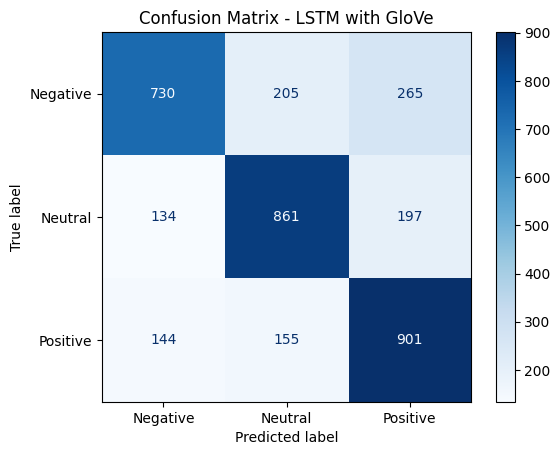

,Model,Accuracy,Precision (0),Recall (0),F1 (0),Precision (1),Recall (1),F1 (1),Precision (2),Recall (2),F1 (2),Macro F1,Weighted F1
0,LSTM_with_GloVe,0.693764,0.724206,0.608333,0.661232,0.70516,0.722315,0.713634,0.661042,0.750833,0.703082,0.69265,0.692603


In [ ]:
import tensorflow as tf
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

# Path to the saved model (with GloVe)
model_path = "/content/drive/MyDrive/Mis ML Modelos/Modelos_Semanticos/Semantic_Analysis_DynaSent/lstm_model_DynaSent_with_glove.h5"

# Load the pre-trained model (with GloVe)
model_glove = tf.keras.models.load_model(model_path)

# Load the tokenizer from training process (make sure this is saved or re-fit)
# If the tokenizer was saved, load it like this:
# import pickle
# with open("tokenizer.pickle", "rb") as handle:
#     tokenizer = pickle.load(handle)

# If you don't have the tokenizer saved, re-create and fit the tokenizer as follows:
balanced_train_Dynasent_clean = pd.read_csv("/content/balanced_train_Dynasent_clean.csv")
train_texts = balanced_train_Dynasent_clean['Text'].astype(str).tolist()

max_features = 24093
tokenizer = Tokenizer(num_words=max_features, lower=True, oov_token="<OOV>")
tokenizer.fit_on_texts(train_texts)

# Load the balanced test data
balanced_test_Dynasent_clean = pd.read_csv("/content/balanced_test_Dynasent_clean.csv")

# Prepare test data (texts and labels)
test_texts = balanced_test_Dynasent_clean['Text'].astype(str).tolist()
test_labels = balanced_test_Dynasent_clean['Label'].tolist()

# Tokenization and padding for test data
X_test = tokenizer.texts_to_sequences(test_texts)

# Clip indices to max_features - 1 (to match training preprocessing)
X_test = [[i if i < max_features else 1 for i in seq] for seq in X_test]

# Padding the sequences to the same length as training data
X_test = pad_sequences(X_test, maxlen=100)  # Adjust maxlen as per your training sequence length

# Encode labels for test
Y_test = tf.keras.utils.to_categorical(test_labels, num_classes=3)

# ==== Model test Function ====
def evaluate_model(model, X_test, Y_test, name="Model"):
    # Predicting
    Y_pred_probs = model.predict(X_test)
    Y_pred = np.argmax(Y_pred_probs, axis=1)  # Get the class with the highest probability
    Y_true = np.argmax(Y_test, axis=1)  # Get the true class labels

    # Metrics
    acc = accuracy_score(Y_true, Y_pred)
    report = classification_report(Y_true, Y_pred, output_dict=True)

    # Prepare the row of metrics
    row = {
        "Model": name,
        "Accuracy": acc,
        "Precision (0)": report["0"]["precision"],
        "Recall (0)": report["0"]["recall"],
        "F1 (0)": report["0"]["f1-score"],
        "Precision (1)": report["1"]["precision"],
        "Recall (1)": report["1"]["recall"],
        "F1 (1)": report["1"]["f1-score"],
        "Precision (2)": report["2"]["precision"],
        "Recall (2)": report["2"]["recall"],
        "F1 (2)": report["2"]["f1-score"],
        "Macro F1": report["macro avg"]["f1-score"],
        "Weighted F1": report["weighted avg"]["f1-score"]
    }
    return row, Y_true, Y_pred

# List to store summary data
summary_data = []

# Evaluate the model on the test data
row, Y_true, Y_pred = evaluate_model(model_glove, X_test, Y_test, name="LSTM_with_GloVe")

# Append the row to summary data
summary_data.append(row)

# Print full report and confusion matrix
print(f"Accuracy: {row['Accuracy']:.4f}")
print(classification_report(Y_true, Y_pred, target_names=["Negative", "Neutral", "Positive"]))

# Confusion Matrix Visualization
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(Y_true, Y_pred), display_labels=["Negative", "Neutral", "Positive"])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - LSTM with GloVe")
plt.show()

# Convert summary_data into a DataFrame
summary_df_DynaSent = pd.DataFrame(summary_data)
display(summary_df_DynaSent)

# Save to CSV
summary_df_DynaSent.to_csv("/content/drive/MyDrive/Mis ML Modelos/Modelos_Semanticos/Semantic_Analysis_DynaSent/resume_all_models_LSTM_DynaSent_withGlove_test.csv", index=False)


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np
import pandas as pd

# === Load both models ===
glove_model_path = "/content/drive/MyDrive/Mis ML Modelos/Modelos_Semanticos/Semantic_Analysis_DynaSent/lstm_model_DynaSent_with_glove.h5"
noglove_model_path = "/content/drive/MyDrive/Mis ML Modelos/Modelos_Semanticos/Semantic_Analysis_DynaSent/lstm_model_DynaSent_without_glove.h5"

model_glove = tf.keras.models.load_model(glove_model_path)
model_noglove = tf.keras.models.load_model(noglove_model_path)

# === Load training data to fit tokenizer (same preprocessing for both models) ===
balanced_train_Dynasent_clean = pd.read_csv("/content/balanced_train_Dynasent_clean.csv")
train_texts = balanced_train_Dynasent_clean['Text'].astype(str).tolist()

# === Tokenizer Setup ===
max_features = 10000
tokenizer = Tokenizer(num_words=max_features, lower=True, oov_token="<OOV>")
tokenizer.fit_on_texts(train_texts)

# === Sample texts to test ===
new_texts = [
    "Great", "Amazing", "Well done", "Terrible", "Pathetic", "Poorly done",
    "Oooh, wow!", "That is terrific!", "That’s awesome!",
    "This is terrible!", "Absolutely awful!", "This is so disappointing!",
    "I wasn’t looking forward to it anyway", "Oh, this is just what I needed right now",
    "Really?", "Is that your best attempt?", "How could this possibly get any worse?",
    "How sweet the moonlight sleeps upon this bank!",
    "Blow, winds, and crack your cheeks! rage! blow!",
    "Fair is foul, and foul is fair: Hover through the fog and filthy air."
]

# === Tokenization & Padding ===
X_new = tokenizer.texts_to_sequences(new_texts)
X_new = [[i if i < max_features else 1 for i in seq] for seq in X_new]
X_new = pad_sequences(X_new, maxlen=100)

# === Predictions ===
pred_probs_glove = model_glove.predict(X_new)
pred_probs_noglove = model_noglove.predict(X_new)

pred_labels_glove = np.argmax(pred_probs_glove, axis=1)
pred_labels_noglove = np.argmax(pred_probs_noglove, axis=1)

label_map = {0: "Negative", 1: "Neutral", 2: "Positive"}
pred_classes_glove = [label_map[l] for l in pred_labels_glove]
pred_classes_noglove = [label_map[l] for l in pred_labels_noglove]

# === Print Comparison ===
print(f"{'Text':<60} {'GloVe':<15} {'No GloVe':<15}")
print("=" * 90)
for text, pred_g, pred_ng in zip(new_texts, pred_classes_glove, pred_classes_noglove):
    print(f"{text:<60} {pred_g:<15} {pred_ng:<15}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 504ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 525ms/step
Text                                                         GloVe           No GloVe       
Great                                                        Positive        Positive       
Amazing                                                      Positive        Positive       
Well done                                                    Positive        Neutral        
Terrible                                                     Negative        Negative       
Pathetic                                                     Negative        Neutral        
Poorly done                                                  Negative        Neutral        
Oooh, wow!                                                   Positive        Negative       
That is terrific!                                            Positive        Negative       
That’s awesome!                                              Positive        Positive

113/113 ━━━━━━━━━━━━━━━━━━━━ 18s 156ms/step
113/113 ━━━━━━━━━━━━━━━━━━━━ 18s 150ms/step
                Model  Accuracy  Precision (0)  Recall (0)    F1 (0)  \
0     LSTM with GloVe  0.687082       0.724638    0.583333  0.646353   
1  LSTM without GloVe  0.605512       0.505099    0.784167  0.614430   

   Precision (1)  Recall (1)    F1 (1)  Precision (2)  Recall (2)   F1 (2)  \
0       0.690400    0.723993  0.706798       0.657703    0.754167  0.70264   
1       0.665966    0.531879  0.591418       0.772201    0.500000  0.60698   

   Macro F1  Weighted F1  
0  0.685263     0.685215  
1  0.604276     0.604305  


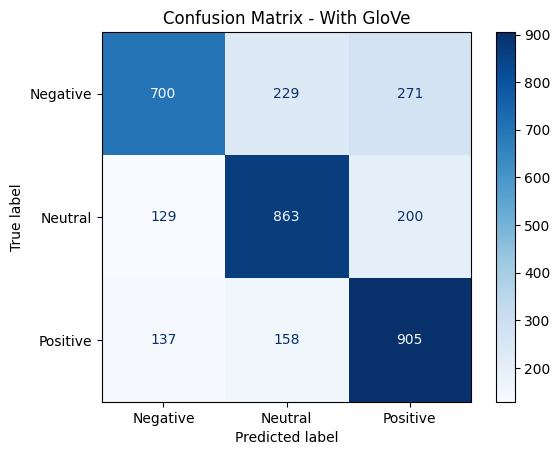

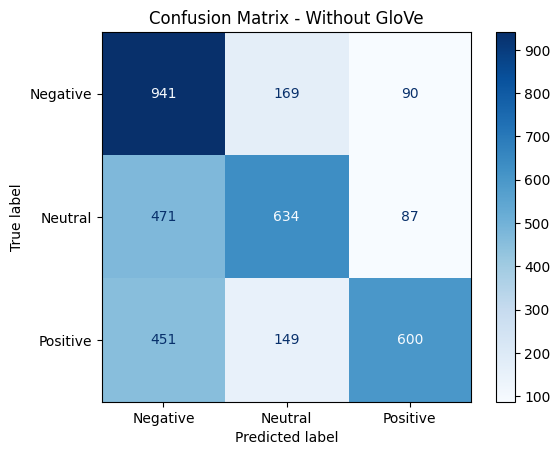

In [ ]:
import tensorflow as tf
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
import matplotlib.pyplot as plt

# === Load both models ===
glove_model_path = "/content/drive/MyDrive/Mis ML Modelos/Modelos_Semanticos/Semantic_Analysis_DynaSent/lstm_model_DynaSent_with_glove.h5"
noglove_model_path = "/content/drive/MyDrive/Mis ML Modelos/Modelos_Semanticos/Semantic_Analysis_DynaSent/lstm_model_DynaSent_without_glove.h5"

model_glove = tf.keras.models.load_model(glove_model_path)
model_noglove = tf.keras.models.load_model(noglove_model_path)

# === Load training data to fit tokenizer ===
balanced_train_Dynasent_clean = pd.read_csv("/content/balanced_train_Dynasent_clean.csv")
train_texts = balanced_train_Dynasent_clean['Text'].astype(str).tolist()

# Tokenizer
max_features = 10000
tokenizer = Tokenizer(num_words=max_features, lower=True, oov_token="<OOV>")
tokenizer.fit_on_texts(train_texts)

# === Load test data ===
balanced_test_Dynasent_clean = pd.read_csv("/content/balanced_test_Dynasent_clean.csv")
test_texts = balanced_test_Dynasent_clean['Text'].astype(str).tolist()
test_labels = balanced_test_Dynasent_clean['Label'].tolist()

# Tokenize and pad test texts
X_test = tokenizer.texts_to_sequences(test_texts)
X_test = [[i if i < max_features else 1 for i in seq] for seq in X_test]
X_test = pad_sequences(X_test, maxlen=100)

# One-hot encode labels
Y_test = tf.keras.utils.to_categorical(test_labels, num_classes=3)

# === Evaluation Function ===
def evaluate_model(model, X_test, Y_test, name="Model"):
    Y_pred_probs = model.predict(X_test)
    Y_pred = np.argmax(Y_pred_probs, axis=1)
    Y_true = np.argmax(Y_test, axis=1)

    acc = accuracy_score(Y_true, Y_pred)
    report = classification_report(Y_true, Y_pred, output_dict=True)

    row = {
        "Model": name,
        "Accuracy": acc,
        "Precision (0)": report["0"]["precision"],
        "Recall (0)": report["0"]["recall"],
        "F1 (0)": report["0"]["f1-score"],
        "Precision (1)": report["1"]["precision"],
        "Recall (1)": report["1"]["recall"],
        "F1 (1)": report["1"]["f1-score"],
        "Precision (2)": report["2"]["precision"],
        "Recall (2)": report["2"]["recall"],
        "F1 (2)": report["2"]["f1-score"],
        "Macro F1": report["macro avg"]["f1-score"],
        "Weighted F1": report["weighted avg"]["f1-score"]
    }
    return row, Y_true, Y_pred

# === Evaluate both models ===
results = []

row_glove, y_true_glove, y_pred_glove = evaluate_model(model_glove, X_test, Y_test, name="LSTM with GloVe")
row_noglove, y_true_noglove, y_pred_noglove = evaluate_model(model_noglove, X_test, Y_test, name="LSTM without GloVe")

results.append(row_glove)
results.append(row_noglove)

# === Display Summary ===
summary_df = pd.DataFrame(results)
print(summary_df)

# === Optional: Confusion Matrices ===
for name, y_true, y_pred in [("With GloVe", y_true_glove, y_pred_glove), ("Without GloVe", y_true_noglove, y_pred_noglove)]:
    disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_true, y_pred), display_labels=["Negative", "Neutral", "Positive"])
    disp.plot(cmap='Blues')
    plt.title(f"Confusion Matrix - {name}")
    plt.show()


# BiLSTM

## Train

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, LSTM, SpatialDropout1D, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import pandas as pd
import numpy as np

# ==== Hyperparameters ====
max_features = 24093      # Increased from 10k to 25k to cover more unique words
max_len = 128             # Fixed to 130, based on your max cleaned text length
embedding_dim = 300
lstm_out = 196
batch_size = 64

train_texts = balanced_train_Dynasent_clean['Text'].astype(str).tolist()
train_labels = balanced_train_Dynasent_clean['Label'].tolist()

val_texts = balanced_val_Dynasent_clean['Text'].astype(str).tolist()
val_labels = balanced_val_Dynasent_clean['Label'].tolist()

# ==== TEXT TOKENIZATION ====
tokenizer = Tokenizer(num_words=max_features, lower=True, oov_token="<OOV>")
tokenizer.fit_on_texts(train_texts)
X_train = tokenizer.texts_to_sequences(train_texts)
X_val = tokenizer.texts_to_sequences(val_texts)

# ==== CLIP INDICES TO max_features - 1 ====
X_train = [[i if i < max_features else 1 for i in seq] for seq in X_train]
X_val = [[i if i < max_features else 1 for i in seq] for seq in X_val]

# ==== PADDING ====
max_len = max([len(x) for x in X_train + X_val])
X_train = pad_sequences(X_train, maxlen=max_len)
X_val = pad_sequences(X_val, maxlen=max_len)

# ==== ENCODE LABELS ====
Y_train = tf.keras.utils.to_categorical(train_labels, num_classes=3)
Y_val = tf.keras.utils.to_categorical(val_labels, num_classes=3)

word_index = tokenizer.word_index
num_words = min(max_features, len(word_index) + 1)
X = X_train  # For model definition

# ==== Evaluation Function ====
def evaluate_model(model, X_val, Y_val, dataset_name="Model"):
    Y_pred_probs = model.predict(X_val)
    Y_pred = np.argmax(Y_pred_probs, axis=1)
    Y_true = np.argmax(Y_val, axis=1)
    report = classification_report(Y_true, Y_pred, output_dict=True)
    accuracy = accuracy_score(Y_true, Y_pred)
    cm = confusion_matrix(Y_true, Y_pred)
    return {
        "Dataset": dataset_name,
        "Accuracy": accuracy,
        "Precision (Negative)": report["0"]["precision"],
        "Recall (Negative)": report["0"]["recall"],
        "F1-Score (Negative)": report["0"]["f1-score"],
        "Precision (Neutral)": report["1"]["precision"],
        "Recall (Neutral)": report["1"]["recall"],
        "F1-Score (Neutral)": report["1"]["f1-score"],
        "Precision (Positive)": report["2"]["precision"],
        "Recall (Positive)": report["2"]["recall"],
        "F1-Score (Positive)": report["2"]["f1-score"],
        "confusion_matrix": cm
    }

# ==== Helper to Build Model with BiLSTM ====
def build_lstm_model(use_glove=False, embedding_matrix=None, trainable=True):
    embedding_args = {
        "input_dim": num_words,
        "output_dim": embedding_dim,
        "trainable": trainable
    }
    if use_glove:
        embedding_args["weights"] = [embedding_matrix]

    model = Sequential([
        Embedding(**embedding_args),
        SpatialDropout1D(0.4),
        Bidirectional(LSTM(lstm_out, dropout=0.2, recurrent_dropout=0.2)),
        Dense(3, activation='softmax')
    ])
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    model.build(input_shape=(None, X.shape[1]))
    return model

# ==== Train and Evaluate Model ====
def train_and_evaluate(model, name):
    early_stopping = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
    model.fit(
        X_train, Y_train,
        epochs=6,
        batch_size=batch_size,
        validation_data=(X_val, Y_val),
        callbacks=[early_stopping],
        verbose=1
    )
    return evaluate_model(model, X_val, Y_val, dataset_name=name)

# ==== Load GloVe Embeddings ====
embedding_index = {}
glove_path = 'glove.840B.300d.txt'  # Make sure this file is available
with open(glove_path, encoding='utf8') as f:
    for line in f:
        values = line.strip().split()
        word = values[0]
        try:
            vector = np.asarray(values[1:], dtype='float32')
            if vector.shape[0] == embedding_dim:
                embedding_index[word] = vector
        except ValueError:
            continue
print(f"Loaded {len(embedding_index)} valid GloVe vectors.")

# ==== Create Embedding Matrix ====
embedding_matrix = np.zeros((num_words, embedding_dim))
for word, i in word_index.items():
    if i < max_features:
        embedding_vector = embedding_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector

# ==== Run Comparisons ====
# With GloVe (frozen)
model_glove = build_lstm_model(use_glove=True, embedding_matrix=embedding_matrix, trainable=False)
results_glove = train_and_evaluate(model_glove, name="BiLSTM_With_GloVe")

# Without GloVe (learned embeddings)
model_no_glove = build_lstm_model(use_glove=False, trainable=True)
results_no_glove = train_and_evaluate(model_no_glove, name="BiLSTM_Without_GloVe")

# ==== SAVE MODELS ====
model_glove.save("/content/drive/MyDrive/Mis ML Modelos/Modelos_Semanticos/Semantic_Analysis_DynaSent/bilstm_model_DynaSent_with_glove.h5")
model_no_glove.save("/content/drive/MyDrive/Mis ML Modelos/Modelos_Semanticos/Semantic_Analysis_DynaSent/bilstm_model_DynaSent_without_glove.h5")

# ==== Print Results ====
comparison_df = pd.DataFrame([
    {"Model": "BiLSTM With GloVe", **results_glove},
    {"Model": "BiLSTM Without GloVe", **results_no_glove}
])
comparison_df.drop(columns=["confusion_matrix"], inplace=True)
print(comparison_df.T)


Loaded 2195876 valid GloVe vectors.
Epoch 1/6
657/657 ━━━━━━━━━━━━━━━━━━━━ 560s 833ms/step - accuracy: 0.5194 - loss: 0.9800 - val_accuracy: 0.6386 - val_loss: 0.8167
Epoch 2/6
657/657 ━━━━━━━━━━━━━━━━━━━━ 550s 837ms/step - accuracy: 0.5979 - loss: 0.8743 - val_accuracy: 0.6528 - val_loss: 0.7911
Epoch 3/6
657/657 ━━━━━━━━━━━━━━━━━━━━ 557s 830ms/step - accuracy: 0.6165 - loss: 0.8449 - val_accuracy: 0.6633 - val_loss: 0.7772
Epoch 4/6
657/657 ━━━━━━━━━━━━━━━━━━━━ 556s 821ms/step - accuracy: 0.6305 - loss: 0.8212 - val_accuracy: 0.6731 - val_loss: 0.7524
Epoch 5/6
657/657 ━━━━━━━━━━━━━━━━━━━━ 567s 829ms/step - accuracy: 0.6479 - loss: 0.7885 - val_accuracy: 0.6761 - val_loss: 0.7422
Epoch 6/6
657/657 ━━━━━━━━━━━━━━━━━━━━ 554s 816ms/step - accuracy: 0.6581 - loss: 0.7675 - val_accuracy: 0.6778 - val_loss: 0.7447
113/113 ━━━━━━━━━━━━━━━━━━━━ 20s 165ms/step
Epoch 1/6
657/657 ━━━━━━━━━━━━━━━━━━━━ 614s 925ms/step - accuracy: 0.4841 - loss: 0.9989 - val_accuracy: 0.6202 - val_loss: 0.8511
Epo

                                      0                     1
Model                 BiLSTM With GloVe  BiLSTM Without GloVe
Dataset               BiLSTM_With_GloVe  BiLSTM_Without_GloVe
Accuracy                       0.676127                0.6202
Precision (Negative)           0.635424              0.544926
Recall (Negative)              0.718098              0.703086
F1-Score (Negative)            0.674236              0.613984
Precision (Neutral)            0.678226              0.644809
Recall (Neutral)               0.703177              0.591973
F1-Score (Neutral)             0.690476              0.617262
Precision (Positive)           0.728729              0.714436
Recall (Positive)              0.607173              0.565471
F1-Score (Positive)             0.66242              0.631285


## Eval

113/113 ━━━━━━━━━━━━━━━━━━━━ 20s 155ms/step
113/113 ━━━━━━━━━━━━━━━━━━━━ 17s 141ms/step
                Model  Accuracy  Precision (0)  Recall (0)    F1 (0)  \
0     LSTM with GloVe  0.685969       0.644162    0.675833  0.659618   
1  LSTM without GloVe  0.611915       0.510112    0.756667  0.609396   

   Precision (1)  Recall (1)    F1 (1)  Precision (2)  Recall (2)    F1 (2)  \
0       0.684455    0.742450  0.712274       0.738462    0.640000  0.685714   
1       0.663561    0.537752  0.594069       0.767139    0.540833  0.634409   

   Macro F1  Weighted F1  
0  0.685869     0.685810  
1  0.612624     0.612666  


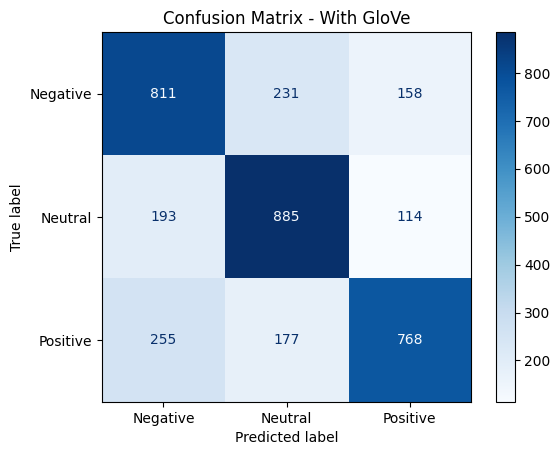

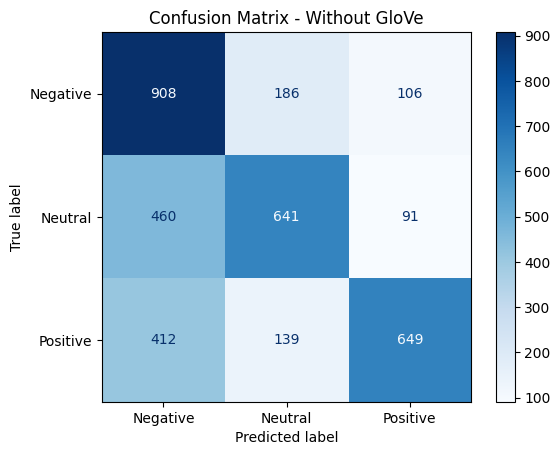

In [ ]:
import tensorflow as tf
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
import matplotlib.pyplot as plt

# === Load both models ===
glove_model_path = "/content/drive/MyDrive/Mis ML Modelos/Modelos_Semanticos/Semantic_Analysis_DynaSent/bilstm_model_DynaSent_with_glove.h5"
noglove_model_path = "/content/drive/MyDrive/Mis ML Modelos/Modelos_Semanticos/Semantic_Analysis_DynaSent/bilstm_model_DynaSent_without_glove.h5"

model_glove = tf.keras.models.load_model(glove_model_path)
model_noglove = tf.keras.models.load_model(noglove_model_path)

# === Load training data to fit tokenizer ===
balanced_train_Dynasent_clean = pd.read_csv("/content/balanced_train_Dynasent_clean.csv")
train_texts = balanced_train_Dynasent_clean['Text'].astype(str).tolist()

# Tokenizer
max_features = 10000
tokenizer = Tokenizer(num_words=max_features, lower=True, oov_token="<OOV>")
tokenizer.fit_on_texts(train_texts)

# === Load test data ===
balanced_test_Dynasent_clean = pd.read_csv("/content/balanced_test_Dynasent_clean.csv")
test_texts = balanced_test_Dynasent_clean['Text'].astype(str).tolist()
test_labels = balanced_test_Dynasent_clean['Label'].tolist()

# Tokenize and pad test texts
X_test = tokenizer.texts_to_sequences(test_texts)
X_test = [[i if i < max_features else 1 for i in seq] for seq in X_test]
X_test = pad_sequences(X_test, maxlen=100)

# One-hot encode labels
Y_test = tf.keras.utils.to_categorical(test_labels, num_classes=3)

# === Evaluation Function ===
def evaluate_model(model, X_test, Y_test, name="Model"):
    Y_pred_probs = model.predict(X_test)
    Y_pred = np.argmax(Y_pred_probs, axis=1)
    Y_true = np.argmax(Y_test, axis=1)

    acc = accuracy_score(Y_true, Y_pred)
    report = classification_report(Y_true, Y_pred, output_dict=True)

    row = {
        "Model": name,
        "Accuracy": acc,
        "Precision (0)": report["0"]["precision"],
        "Recall (0)": report["0"]["recall"],
        "F1 (0)": report["0"]["f1-score"],
        "Precision (1)": report["1"]["precision"],
        "Recall (1)": report["1"]["recall"],
        "F1 (1)": report["1"]["f1-score"],
        "Precision (2)": report["2"]["precision"],
        "Recall (2)": report["2"]["recall"],
        "F1 (2)": report["2"]["f1-score"],
        "Macro F1": report["macro avg"]["f1-score"],
        "Weighted F1": report["weighted avg"]["f1-score"]
    }
    return row, Y_true, Y_pred

# === Evaluate both models ===
results = []

row_glove, y_true_glove, y_pred_glove = evaluate_model(model_glove, X_test, Y_test, name="LSTM with GloVe")
row_noglove, y_true_noglove, y_pred_noglove = evaluate_model(model_noglove, X_test, Y_test, name="LSTM without GloVe")

results.append(row_glove)
results.append(row_noglove)

# === Display Summary ===
summary_df = pd.DataFrame(results)
print(summary_df)

# === Optional: Confusion Matrices ===
for name, y_true, y_pred in [("With GloVe", y_true_glove, y_pred_glove), ("Without GloVe", y_true_noglove, y_pred_noglove)]:
    disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_true, y_pred), display_labels=["Negative", "Neutral", "Positive"])
    disp.plot(cmap='Blues')
    plt.title(f"Confusion Matrix - {name}")
    plt.show()


# BERT

## DynaSent

In [ ]:
!unzip dynasent-v1.1.zip -d dynasent-v1.1

Archive:  dynasent-v1.1.zip
   creating: dynasent-v1.1/dynasent-v1.1/
  inflating: dynasent-v1.1/dynasent-v1.1/dynasent-v1.1-round01-yelp-train.jsonl  
   creating: dynasent-v1.1/__MACOSX/
   creating: dynasent-v1.1/__MACOSX/dynasent-v1.1/
  inflating: dynasent-v1.1/__MACOSX/dynasent-v1.1/._dynasent-v1.1-round01-yelp-train.jsonl  
  inflating: dynasent-v1.1/dynasent-v1.1/dynasent-v1.1-round01-yelp-dev.jsonl  
  inflating: dynasent-v1.1/dynasent-v1.1/dynasent-v1.1-round02-dynabench-test.jsonl  
  inflating: dynasent-v1.1/__MACOSX/dynasent-v1.1/._dynasent-v1.1-round02-dynabench-test.jsonl  
  inflating: dynasent-v1.1/dynasent-v1.1/dynasent-v1.1-round02-dynabench-dev.jsonl  
  inflating: dynasent-v1.1/__MACOSX/dynasent-v1.1/._dynasent-v1.1-round02-dynabench-dev.jsonl  
  inflating: dynasent-v1.1/dynasent-v1.1/dynasent-v1.1-round02-dynabench-train.jsonl  
  inflating: dynasent-v1.1/__MACOSX/dynasent-v1.1/._dynasent-v1.1-round02-dynabench-train.jsonl  
  inflating: dynasent-v1.1/dynasent-v1

### Train

In [ ]:
# Import necessary libraries
import zipfile
import os
import json
import random
from collections import Counter
import tensorflow as tf
from transformers import TFBertForSequenceClassification, BertTokenizer

# Hyperparameters
BATCH_SIZE = 64  # Changed from 32 to 16
EPOCHS = 6       # Increased from 2 to 5
MAX_SEQ_LEN = 128
learning_rate = 1e-5

train_sentences = balanced_train_Dynasent_clean['Text'].astype(str).tolist()
train_labels = balanced_train_Dynasent_clean['Label'].tolist()

val_sentences = balanced_val_Dynasent_clean['Text'].astype(str).tolist()
val_labels = balanced_val_Dynasent_clean['Label'].tolist()

# Load BERT model and tokenizer
model = TFBertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=3)
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

All PyTorch model weights were used when initializing TFBertForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
# Import necessary libraries
import zipfile
import os
import json
import random
from collections import Counter
import tensorflow as tf
from transformers import TFBertForSequenceClassification, BertTokenizer

# Hyperparameters
BATCH_SIZE = 64  # Changed from 32 to 16
EPOCHS = 6       # Increased from 2 to 5
MAX_SEQ_LEN = 128
learning_rate = 1e-5

train_sentences = balanced_train_Dynasent_clean['Text'].astype(str).tolist()
train_labels = balanced_train_Dynasent_clean['Label'].tolist()

val_sentences = balanced_val_Dynasent_clean['Text'].astype(str).tolist()
val_labels = balanced_val_Dynasent_clean['Label'].tolist()

# Load BERT model and tokenizer
model = TFBertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=3)
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

# Encode data
def encode_data(sentences, labels):
    input_ids = []
    attention_masks = []

    for sentence in sentences:
        encoded = tokenizer.encode_plus(
            sentence,
            add_special_tokens=True,
            max_length=MAX_SEQ_LEN,
            padding='max_length',
            truncation=True,
            return_attention_mask=True
        )
        input_ids.append(encoded['input_ids'])
        attention_masks.append(encoded['attention_mask'])

    # Convert to tensors and ensure equal length
    min_length = min(len(input_ids), len(attention_masks), len(labels))
    return (tf.convert_to_tensor(input_ids[:min_length]),
            tf.convert_to_tensor(attention_masks[:min_length]),
            tf.convert_to_tensor(labels[:min_length]))

# Encode training and val data
train_input_ids, train_attention_masks, train_labels = encode_data(train_sentences, train_labels)
val_input_ids, val_attention_masks, val_labels = encode_data(val_sentences, test_labels)

# Check length consistency
print(f"Training set - input IDs: {len(train_input_ids)}, attention masks: {len(train_attention_masks)}, labels: {len(train_labels)}")
print(f"val set - input IDs: {len(val_input_ids)}, attention masks: {len(val_attention_masks)}, labels: {len(val_labels)}")

# Create TensorFlow datasets
train_dataset = tf.data.Dataset.from_tensor_slices(({'input_ids': train_input_ids, 'attention_mask': train_attention_masks}, train_labels))
val_dataset = tf.data.Dataset.from_tensor_slices(({'input_ids': val_input_ids, 'attention_mask': val_attention_masks}, val_labels))

train_dataset = train_dataset.shuffle(len(train_labels)).batch(BATCH_SIZE)
val_dataset = val_dataset.batch(BATCH_SIZE)

# Compile the model with updated optimizer
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate, epsilon=1e-8)
loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
metric = tf.keras.metrics.SparseCategoricalAccuracy('accuracy')

model.compile(optimizer=optimizer, loss=loss, metrics=[metric])

history = model.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=val_dataset  # instead of val_data=val_dataset
)

Training set - input IDs: 42001, attention masks: 42001, labels: 42001
val set - input IDs: 3592, attention masks: 3592, labels: 3592
Epoch 1/6
657/657 [==============================] - 453s 621ms/step - loss: 0.8569 - accuracy: 0.6152 - val_loss: 0.7205 - val_accuracy: 0.6985
Epoch 2/6
657/657 [==============================] - 405s 616ms/step - loss: 0.7097 - accuracy: 0.6990 - val_loss: 0.6757 - val_accuracy: 0.7227
Epoch 3/6
657/657 [==============================] - 405s 617ms/step - loss: 0.6192 - accuracy: 0.7471 - val_loss: 0.6761 - val_accuracy: 0.7169
Epoch 4/6
657/657 [==============================] - 405s 617ms/step - loss: 0.5234 - accuracy: 0.7934 - val_loss: 0.7004 - val_accuracy: 0.7313
Epoch 5/6
657/657 [==============================] - 405s 617ms/step - loss: 0.4214 - accuracy: 0.8388 - val_loss: 0.7565 - val_accuracy: 0.7210
Epoch 6/6
657/657 [==============================] - 405s 616ms/step - loss: 0.3353 - accuracy: 0.8763 - val_loss: 0.8627 - val_accuracy: 0.7

In [ ]:
model.save_pretrained('/content/drive/MyDrive/Mis ML Modelos/Modelos_Semanticos/Semantic_Analysis_DynaSent/3BERT_ROUND1_dynasent_model')
tokenizer.save_pretrained('/content/drive/MyDrive/Mis ML Modelos/Modelos_Semanticos/Semantic_Analysis_DynaSent/3BERT_ROUND1_dynasent_model')

('/content/drive/MyDrive/Mis ML Modelos/Modelos_Semanticos/Semantic_Analysis_DynaSent/3BERT_ROUND1_dynasent_model/tokenizer_config.json',
 '/content/drive/MyDrive/Mis ML Modelos/Modelos_Semanticos/Semantic_Analysis_DynaSent/3BERT_ROUND1_dynasent_model/special_tokens_map.json',
 '/content/drive/MyDrive/Mis ML Modelos/Modelos_Semanticos/Semantic_Analysis_DynaSent/3BERT_ROUND1_dynasent_model/vocab.txt',
 '/content/drive/MyDrive/Mis ML Modelos/Modelos_Semanticos/Semantic_Analysis_DynaSent/3BERT_ROUND1_dynasent_model/added_tokens.json')

### Eval

In [ ]:
from transformers import TFBertForSequenceClassification, BertTokenizer
import tensorflow as tf
import pandas as pd

# Load saved model and tokenizer
model = TFBertForSequenceClassification.from_pretrained('/content/drive/MyDrive/Mis ML Modelos/Modelos_Semanticos/Semantic_Analysis_DynaSent/3BERT_ROUND1_dynasent_model')
tokenizer = BertTokenizer.from_pretrained('/content/drive/MyDrive/Mis ML Modelos/Modelos_Semanticos/Semantic_Analysis_DynaSent/3BERT_ROUND1_dynasent_model')

Some layers from the model checkpoint at /content/drive/MyDrive/Mis ML Modelos/Modelos_Semanticos/Semantic_Analysis_DynaSent/3BERT_ROUND1_dynasent_model were not used when initializing TFBertForSequenceClassification: ['dropout_75']
- This IS expected if you are initializing TFBertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
All the layers of TFBertForSequenceClassification were initialized from the model checkpoint at /content/drive/MyDrive/Mis ML Modelos/Modelos_Semanticos/Semantic_Analysis_DynaSent/3BERT_ROUND1_dynasent_model.
If your task is similar to the task the model of the checkpoi

57/57 [==============================] - 14s 199ms/step
Accuracy: 0.7183
              precision    recall  f1-score   support

    Negative       0.73      0.69      0.71      1200
     Neutral       0.75      0.70      0.72      1192
    Positive       0.68      0.77      0.72      1200

    accuracy                           0.72      3592
   macro avg       0.72      0.72      0.72      3592
weighted avg       0.72      0.72      0.72      3592



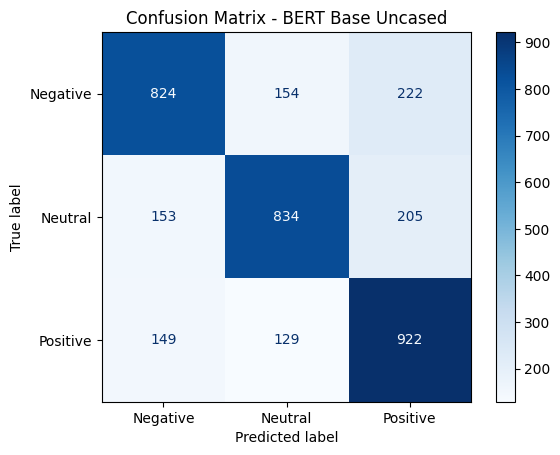

,Model,Accuracy,Precision (0),Recall (0),F1 (0),Precision (1),Recall (1),F1 (1),Precision (2),Recall (2),F1 (2),Macro F1,Weighted F1
0,BERT_base_uncased,0.718263,0.731794,0.686667,0.708512,0.746643,0.699664,0.722391,0.683469,0.768333,0.723421,0.718108,0.718098


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

balanced_test_Dynasent_clean = pd.read_csv("/content/balanced_test_Dynasent_clean.csv")

test_sentences = balanced_test_Dynasent_clean['Text'].astype(str).tolist()
test_labels = balanced_test_Dynasent_clean['Label'].tolist()

# Function to evaluate BERT model
def evaluate_model_bert(model, tokenizer, df_test, name="BERT_base_uncased"):
    test_sentences = df_test['Text'].astype(str).tolist()
    Y_true = df_test['Label'].tolist()

    # Encode test data
    def encode(sentences):
        input_ids, attention_masks = [], []
        for sent in sentences:
            encoded = tokenizer.encode_plus(
                sent,
                add_special_tokens=True,
                max_length=128,
                padding='max_length',
                truncation=True,
                return_attention_mask=True
            )
            input_ids.append(encoded['input_ids'])
            attention_masks.append(encoded['attention_mask'])
        return tf.convert_to_tensor(input_ids), tf.convert_to_tensor(attention_masks)

    test_input_ids, test_attention_masks = encode(test_sentences)

    test_dataset = tf.data.Dataset.from_tensor_slices(
        ({'input_ids': test_input_ids, 'attention_mask': test_attention_masks})
    ).batch(64)

    # Predict
    predictions = model.predict(test_dataset).logits
    Y_pred = np.argmax(predictions, axis=1)

    # Metrics
    acc = accuracy_score(Y_true, Y_pred)
    report = classification_report(Y_true, Y_pred, output_dict=True)

    # Prepare the row of metrics
    row = {
        "Model": name,
        "Accuracy": acc,
        "Precision (0)": report["0"]["precision"],
        "Recall (0)": report["0"]["recall"],
        "F1 (0)": report["0"]["f1-score"],
        "Precision (1)": report["1"]["precision"],
        "Recall (1)": report["1"]["recall"],
        "F1 (1)": report["1"]["f1-score"],
        "Precision (2)": report["2"]["precision"],
        "Recall (2)": report["2"]["recall"],
        "F1 (2)": report["2"]["f1-score"],
        "Macro F1": report["macro avg"]["f1-score"],
        "Weighted F1": report["weighted avg"]["f1-score"]
    }

    return row, Y_true, Y_pred

# List to store summary data
summary_data = []

# Evaluate the model on test data
row, Y_true, Y_pred = evaluate_model_bert(model, tokenizer, balanced_test_Dynasent_clean, name="BERT_base_uncased")

# Append the row to summary data
summary_data.append(row)

# Print full report and confusion matrix
print(f"Accuracy: {row['Accuracy']:.4f}")
print(classification_report(Y_true, Y_pred, target_names=["Negative", "Neutral", "Positive"]))

# Confusion Matrix Visualization
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(Y_true, Y_pred), display_labels=["Negative", "Neutral", "Positive"])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - BERT Base Uncased")
plt.show()

# Convert summary_data into a DataFrame
summary_df_DynaSent = pd.DataFrame(summary_data)
display(summary_df_DynaSent)

# Save to CSV
summary_df_DynaSent.to_csv("/content/drive/MyDrive/Mis ML Modelos/Modelos_Semanticos/Semantic_Analysis_DynaSent/resume_all_models_BERT_DynaSent_test.csv", index=False)


# BERT++

## DynaSent

### Train

In [ ]:
# Import necessary libraries
import tensorflow as tf
from transformers import TFBertForSequenceClassification, BertTokenizer

# Hyperparameters
BATCH_SIZE = 64
EPOCHS = 6
MAX_SEQ_LEN = 128
learning_rate = 1e-5

# Custom Model with extra layer
class TFBertWithExtraLayer(tf.keras.Model):
    def __init__(self, base_model_name="bert-base-uncased", num_labels=3, dropout_rate=0.15, hidden_dim=768):
        super().__init__()
        self.bert_sc = TFBertForSequenceClassification.from_pretrained(base_model_name, num_labels=num_labels)
        self.hidden = tf.keras.layers.Dense(hidden_dim, activation='relu')
        self.dropout = tf.keras.layers.Dropout(dropout_rate)
        self.classifier = tf.keras.layers.Dense(num_labels)

    def call(self, inputs, training=False):
        outputs = self.bert_sc(inputs, training=training)
        x = self.hidden(outputs.logits)
        x = self.dropout(x, training=training)
        return self.classifier(x)

# Data Preparation
train_sentences = balanced_train_Dynasent_clean['Text'].astype(str).tolist()
train_labels = balanced_train_Dynasent_clean['Label'].tolist()
val_sentences = balanced_val_Dynasent_clean['Text'].astype(str).tolist()
val_labels = balanced_val_Dynasent_clean['Label'].tolist()

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

def encode_data(sentences, labels):
    input_ids, attention_masks = [], []
    for sentence in sentences:
        encoded = tokenizer.encode_plus(
            sentence,
            add_special_tokens=True,
            max_length=MAX_SEQ_LEN,
            padding='max_length',
            truncation=True,
            return_attention_mask=True
        )
        input_ids.append(encoded['input_ids'])
        attention_masks.append(encoded['attention_mask'])

    min_length = min(len(input_ids), len(attention_masks), len(labels))
    return (tf.convert_to_tensor(input_ids[:min_length]),
            tf.convert_to_tensor(attention_masks[:min_length]),
            tf.convert_to_tensor(labels[:min_length]))

# Encoding data
train_input_ids, train_attention_masks, train_labels = encode_data(train_sentences, train_labels)
val_input_ids, val_attention_masks, val_labels = encode_data(val_sentences, val_labels)

# Create TensorFlow datasets
train_dataset = tf.data.Dataset.from_tensor_slices(({'input_ids': train_input_ids, 'attention_mask': train_attention_masks}, train_labels)).shuffle(len(train_labels)).batch(BATCH_SIZE)
val_dataset = tf.data.Dataset.from_tensor_slices(({'input_ids': val_input_ids, 'attention_mask': val_attention_masks}, val_labels)).batch(BATCH_SIZE)

# Initialize custom model
custom_model = TFBertWithExtraLayer()

# Compile model
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate, epsilon=1e-8)
loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
metric = tf.keras.metrics.SparseCategoricalAccuracy('accuracy')

custom_model.compile(optimizer=optimizer, loss=loss, metrics=[metric])

# Train model
history = custom_model.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=val_dataset
)

All PyTorch model weights were used when initializing TFBertForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/6
657/657 [==============================] - 447s 620ms/step - loss: 0.9306 - accuracy: 0.5666 - val_loss: 0.7410 - val_accuracy: 0.6962
Epoch 2/6
657/657 [==============================] - 405s 616ms/step - loss: 0.7284 - accuracy: 0.7027 - val_loss: 0.7019 - val_accuracy: 0.7142
Epoch 3/6
657/657 [==============================] - 404s 616ms/step - loss: 0.6305 - accuracy: 0.7474 - val_loss: 0.6763 - val_accuracy: 0.7237
Epoch 4/6
657/657 [==============================] - 405s 616ms/step - loss: 0.5313 - accuracy: 0.7945 - val_loss: 0.6854 - val_accuracy: 0.7220
Epoch 5/6
657/657 [==============================] - 405s 616ms/step - loss: 0.4417 - accuracy: 0.8360 - val_loss: 0.7259 - val_accuracy: 0.7243
Epoch 6/6
657/657 [==============================] - 404s 616ms/step - loss: 0.3549 - accuracy: 0.8734 - val_loss: 0.7925 - val_accuracy: 0.7198


In [ ]:
# Define your model save path
model_save_path = "/content/drive/MyDrive/Mis ML Modelos/Modelos_Semanticos/Semantic_Analysis_DynaSent/3BERTPlus_ROUND1_dynasent_model"

# Save the entire model (TensorFlow SavedModel format)
custom_model.save(model_save_path)

All PyTorch model weights were used when initializing TFBertForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


57/57 [==============================] - 14s 197ms/step
Accuracy: 0.7280
              precision    recall  f1-score   support

    Negative       0.73      0.74      0.73      1200
     Neutral       0.73      0.73      0.73      1192
    Positive       0.72      0.72      0.72      1200

    accuracy                           0.73      3592
   macro avg       0.73      0.73      0.73      3592
weighted avg       0.73      0.73      0.73      3592



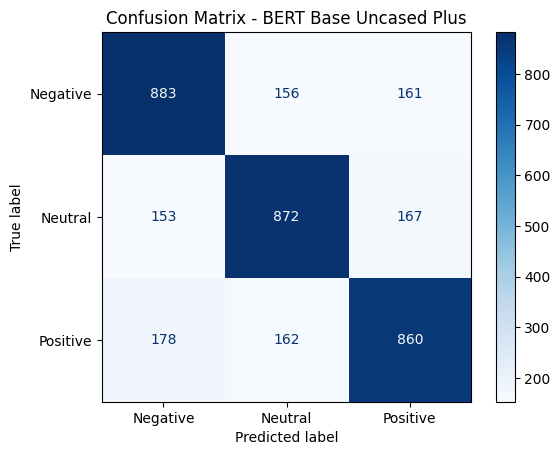

,Model,Accuracy,Precision (0),Recall (0),F1 (0),Precision (1),Recall (1),F1 (1),Precision (2),Recall (2),F1 (2),Macro F1,Weighted F1
0,BERT_base_uncased_plus,0.728007,0.727348,0.735833,0.731566,0.732773,0.731544,0.732158,0.723906,0.716667,0.720268,0.727997,0.727988


In [ ]:
# Imports
import tensorflow as tf
from transformers import BertTokenizer
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Define custom class (necessary to load your custom model)
class TFBertWithExtraLayer(tf.keras.Model):
    def __init__(self, base_model_name="bert-base-uncased", num_labels=3, dropout_rate=0.15, hidden_dim=768):
        super().__init__()
        from transformers import TFBertForSequenceClassification
        self.bert_sc = TFBertForSequenceClassification.from_pretrained(base_model_name, num_labels=num_labels)
        self.hidden = tf.keras.layers.Dense(hidden_dim, activation='relu')
        self.dropout = tf.keras.layers.Dropout(dropout_rate)
        self.classifier = tf.keras.layers.Dense(num_labels)

    def call(self, inputs, training=False):
        outputs = self.bert_sc(inputs, training=training)
        x = self.hidden(outputs.logits)
        x = self.dropout(x, training=training)
        return self.classifier(x)

# Load the saved model
model_path = "/content/drive/MyDrive/Mis ML Modelos/Modelos_Semanticos/Semantic_Analysis_DynaSent/3BERTPlus_ROUND1_dynasent_model"
custom_model = tf.keras.models.load_model(
    model_path,
    custom_objects={"TFBertWithExtraLayer": TFBertWithExtraLayer},
    compile=False
)

# Load tokenizer
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

# Load test data
balanced_test_Dynasent_clean = pd.read_csv("/content/balanced_test_Dynasent_clean.csv")
test_sentences = balanced_test_Dynasent_clean['Text'].astype(str).tolist()
test_labels = balanced_test_Dynasent_clean['Label'].tolist()

# Tokenization function
MAX_SEQ_LEN = 128
def tokenize_sentences(sentences):
    input_ids, attention_masks = [], []
    for sentence in sentences:
        encoded = tokenizer.encode_plus(
            sentence,
            add_special_tokens=True,
            max_length=MAX_SEQ_LEN,
            padding='max_length',
            truncation=True,
            return_attention_mask=True
        )
        input_ids.append(encoded['input_ids'])
        attention_masks.append(encoded['attention_mask'])

    return {
        'input_ids': tf.convert_to_tensor(input_ids),
        'attention_mask': tf.convert_to_tensor(attention_masks)
    }

# Prepare test dataset
test_encodings = tokenize_sentences(test_sentences)

# Predictions (fixed version)
logits = custom_model.predict(test_encodings, batch_size=64)
Y_pred = np.argmax(logits, axis=1)
Y_true = np.array(test_labels)

# Metrics
acc = accuracy_score(Y_true, Y_pred)
report = classification_report(Y_true, Y_pred, output_dict=True)

# Prepare summary row
row = {
    "Model": "BERT_base_uncased_plus",
    "Accuracy": acc,
    "Precision (0)": report["0"]["precision"],
    "Recall (0)": report["0"]["recall"],
    "F1 (0)": report["0"]["f1-score"],
    "Precision (1)": report["1"]["precision"],
    "Recall (1)": report["1"]["recall"],
    "F1 (1)": report["1"]["f1-score"],
    "Precision (2)": report["2"]["precision"],
    "Recall (2)": report["2"]["recall"],
    "F1 (2)": report["2"]["f1-score"],
    "Macro F1": report["macro avg"]["f1-score"],
    "Weighted F1": report["weighted avg"]["f1-score"]
}

# Display results
print(f"Accuracy: {acc:.4f}")
print(classification_report(Y_true, Y_pred, target_names=["Negative", "Neutral", "Positive"]))

# Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(Y_true, Y_pred),
                              display_labels=["Negative", "Neutral", "Positive"])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - BERT Base Uncased Plus")
plt.show()

# Save results to CSV
summary_df_DynaSent = pd.DataFrame([row])
summary_df_DynaSent.to_csv("/content/drive/MyDrive/Mis ML Modelos/Modelos_Semanticos/Semantic_Analysis_DynaSent/resume_all_models_BERTPlus_DynaSent_test.csv", index=False)

# Display DataFrame
display(summary_df_DynaSent)